# DiploDatos 2026 - Mentoría "Detección de fraude: ¿Cómo cuido a mis clientes? Machine Learning aplicado a un caso de negocio financiero"
## <font color=blue> Trabajo Práctico N° 3 — Aprendizaje Supervisado

**Integrantes:** Abagnale, Florencia · Karlen, Paula · Luna, Ana María · Pintos, Mauricio José

**Input:** `dataset_curado_fraude.csv`, el `df_model` que generamos y guardamos al final del TP2 (192.516 transacciones, sin nulos ni duplicados, con variables de cliente/transacción, One-Hot Encoding y las componentes `PCA_Subset_1/2`).

**Plan de trabajo:** (0) carga y exploración breve → (1) split train/val/test estratificado → (2) métricas → (3) baselines: modelos ingenuos y una regla de negocio → (4) modelos lineales → (5) modelos de árboles, incluido un árbol legible y XGBoost → (6) ajuste de hiperparámetros con GridSearch + k-fold, umbral de decisión y lectura de negocio → (7) ¿qué tan confiable es la evaluación? (intervalos de confianza y partición por cliente) → (8) conclusiones.

**Tiempo de ejecución:** unos 10 minutos en una máquina de 12 núcleos; en Colab (2 vCPU) bastante más, sobre todo la búsqueda de hiperparámetros.

## 0. Librerías y carga de datos

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from IPython.display import display
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, average_precision_score,
                             precision_recall_curve)
from xgboost import XGBClassifier   # viene instalado en Colab; en local: pip install xgboost

sns.set_context('notebook')
SEED = 42
np.random.seed(SEED)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# XGBoost con tree_method='hist' da resultados levemente distintos según la cantidad de hilos:
# lo fijamos en 2 (lo que tiene Colab) para que los números sean los mismos en cualquier máquina.
XGB_JOBS = 2

# Colores: No Fraude = azul, Fraude = naranja; cada modelo tiene siempre el mismo color en todos los gráficos.
AZUL, NARANJA, GRIS = '#2a78d6', '#eb6834', '#8a8a8a'
COLOR_MODELO = {'LogisticRegression': '#4a3aa7', 'LinearSVC': '#e87ba4', 'DecisionTree': '#eda100',
                'RandomForest': '#1baf7a', 'HistGradientBoosting': '#008300', 'XGBoost': '#e34948'}

In [2]:
# Cargamos el dataset curado del TP2. En Colab, si el archivo no está en el entorno, lo subimos.
RUTA = 'dataset_curado_fraude.csv'
if not os.path.exists(RUTA):
    try:
        from google.colab import files
        files.upload()
    except ImportError:
        raise FileNotFoundError(f'No se encontró {RUTA}. Colocarlo junto a la notebook.')

df_model = pd.read_csv(RUTA)
print('Dimensiones:', df_model.shape)
df_model.head()

Dimensiones: (192516, 34)


,Cliente_Id,Trx_Moneda,Trx_Importe,Es_Fraude,Es_Outlier_Importe,Cliente_Edad,Tiempo_Entre_Trx_Horas,Presencia_Cliente,Trx_Importe_log,Cliente_CantTransacciones,...,TipoTerminal_Agrupamiento_Credenciales Guardadas (Suscripciones),TipoTerminal_Agrupamiento_Pagos de Servicios y Web,Categoria_Rubro_OTROS_RUBROS,Categoria_Rubro_SIN_RUBRO,Categoria_Rubro_Servicios Varios,Cliente_RubroFavorito_Categoria_OTROS_RUBROS,Cliente_RubroFavorito_Categoria_SIN_RUBRO,Cliente_RubroFavorito_Categoria_Servicios Varios,PCA_Subset_1,PCA_Subset_2
0,1,0,40000.0000,0,0,88,6.8468,1,10.5967,0,...,False,False,False,True,False,False,True,False,1.3934,0.6641
1,1,0,40000.0000,0,0,88,0.0092,1,10.5967,1,...,False,False,False,True,False,False,True,False,1.3933,0.6636
2,1,0,40000.0000,0,0,88,0.0103,1,10.5967,2,...,False,False,False,True,False,False,True,False,1.3933,0.6630
3,1,0,30000.0000,0,0,88,0.0106,1,10.3090,3,...,False,False,False,True,False,False,True,False,1.3427,0.7021
4,1,0,40000.0000,0,0,88,288.5125,1,10.5967,4,...,False,False,False,True,False,False,True,False,1.3848,0.6808


### 0.1 Análisis descriptivo y exploratorio breve
Chequeamos tipos, nulos y el balance de clases: el desbalance es la característica más importante del problema y condiciona todas las decisiones de modelado (split, métrica, pesos de clase).

Nulos totales: 0 | Duplicados: 0

Tipos de dato:
float64    16
int64       9
bool        9
Name: count, dtype: int64

Balance de la variable objetivo:
           cantidad       %
Es_Fraude                  
0            191320 99.3788
1              1196  0.6212


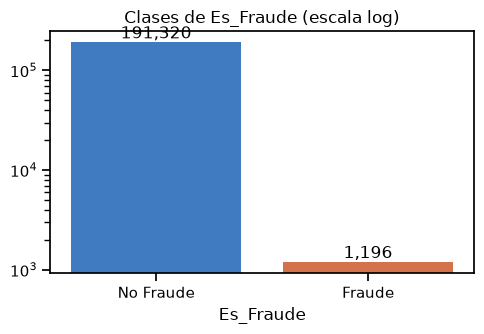

In [3]:
print('Nulos totales:', df_model.isna().sum().sum(), '| Duplicados:', df_model.duplicated().sum())
print('\nTipos de dato:'); print(df_model.dtypes.value_counts())

bal = df_model['Es_Fraude'].value_counts()
bal_pct = df_model['Es_Fraude'].value_counts(normalize=True)*100
print('\nBalance de la variable objetivo:')
print(pd.DataFrame({'cantidad': bal, '%': bal_pct}))

fig, ax = plt.subplots(figsize=(5,3.5))
sns.barplot(x=bal.index.map({0:'No Fraude',1:'Fraude'}), y=bal.values, ax=ax, palette=[AZUL, NARANJA])
ax.set_yscale('log'); ax.set_title('Clases de Es_Fraude (escala log)')
for i,v in enumerate(bal.values): ax.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

In [4]:
# Separamos identificador, target y features (Cliente_Id NO es una feature: identificaría al cliente y no generaliza)
y = df_model['Es_Fraude'].astype(int)
grupos = df_model['Cliente_Id']   # no es feature, pero lo guardamos para la evaluación por cliente (sección 7)
X = df_model.drop(columns=['Es_Fraude', 'Cliente_Id'], errors='ignore')
# las dummies pueden venir como bool/True-False: pasamos todo a numérico
X = X.astype(float)
print('X:', X.shape, '| y:', y.shape)

# Relación de las variables numéricas con el target (diferencia de medias estandarizada, vista rápida)
resumen = X.groupby(y).mean().T
resumen.columns = ['media_NoFraude', 'media_Fraude']
resumen['dif_estandarizada'] = (resumen['media_Fraude']-resumen['media_NoFraude'])/X.std()
resumen.reindex(resumen['dif_estandarizada'].abs().sort_values(ascending=False).index).head(10)

X: (192516, 32) | y: (192516,)


,media_NoFraude,media_Fraude,dif_estandarizada
PCA_Subset_1,0.0307,-4.9137,-2.6921
Trx_Moneda,0.0283,0.4724,2.5606
TipoTerminal_Agrupamiento_Compras y E-commerce,0.0814,0.6965,2.2023
Trx_Importe_log,9.6200,6.5328,-1.5645
Presencia_Cliente,0.6604,0.1446,-1.0866
Categoria_Rubro_SIN_RUBRO,0.5410,0.0000,-1.0850
Categoria_Rubro_OTROS_RUBROS,0.1368,0.4849,1.0066
Categoria_Rubro_Servicios Varios,0.1157,0.4197,0.9440
TipoTerminal_Agrupamiento_Credenciales Guardadas (Suscripciones),0.0347,0.2065,0.9258
PCA_Subset_2,0.0039,-0.6220,-0.4459


**Comentario.** El dataset está completo (sin nulos ni duplicados) y todas las features son numéricas. El fraude representa ~0,62% de las transacciones: un clasificador que diga siempre "No Fraude" tendría ~99,4% de accuracy sin detectar nada. La tabla muestra qué variables difieren más (en desvíos estándar) entre fraude y no fraude; coincide con lo visto en el TP2: ninguna variable separa las clases por sí sola, la señal está en combinaciones y relaciones no lineales, lo que anticipa que los modelos de árboles deberían rendir mejor que los lineales.

## 1. Preparación de los datos: train / validation / test

Usamos una partición **60% train / 20% validation / 20% test**, **estratificada por `Es_Fraude`** (`stratify=y`) para que cada conjunto conserve la proporción de fraude del dataset total. Con sólo ~1.200 fraudes, un split no estratificado podría dejar muy pocos casos positivos en validación o test y volver las métricas inestables.

- **Train:** ajustar modelos. **Validation:** comparar modelos/elegir hiperparámetros y umbral. **Test:** evaluación final, sólo para reportar.

In [5]:
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.40, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

splits = {'Train': y_train, 'Validation': y_val, 'Test': y_test, 'Dataset total': y}
tabla = pd.DataFrame({
    n: {'Total': len(s), '% del total': len(s)/len(y)*100,
        'No Fraude': (s==0).sum(), 'Fraude': (s==1).sum(), '% Fraude': s.mean()*100}
    for n, s in splits.items()}).T
tabla

,Total,% del total,No Fraude,Fraude,% Fraude
Train,115509.0000,59.9997,114791.0000,718.0000,0.6216
Validation,38503.0000,19.9999,38264.0000,239.0000,0.6207
Test,38504.0000,20.0004,38265.0000,239.0000,0.6207
Dataset total,192516.0000,100.0000,191320.0000,1196.0000,0.6212


**Comentario.** Las proporciones respecto al total son 60/20/20 y el porcentaje de fraude es prácticamente idéntico en los cuatro conjuntos (~0,62%), por lo que la estratificación funcionó. Cada conjunto de evaluación (val y test) tiene 239 casos de fraude: suficientes para comparar modelos, aunque las métricas de la clase positiva van a tener ruido (lo medimos en la sección 7.1).

> **Limitación a tener en cuenta:** el split es aleatorio, así que transacciones de un mismo cliente caen a la vez en train, validación y test, y en el TP2 vimos que ~94% del fraude se concentra en octubre–diciembre. Lo ideal sería validar también agrupando por cliente y con un corte temporal. La partición **por cliente** sí la podemos hacer, porque `df_model` conserva `Cliente_Id`: la hacemos en la sección 7.2. El corte temporal requeriría recuperar la fecha desde el archivo original (`df_model` no la conserva), así que queda fuera de este TP. Seguimos la consigna con el split estratificado y medimos después cuánto de su resultado se sostiene.

## 2. Métrica a optimizar y funciones de evaluación

En detección de fraude **el Accuracy no sirve**: con 99,4% de "No Fraude", el modelo trivial ya lo alcanza. Lo que importa es la clase positiva:
- **Recall:** qué proporción de los fraudes reales detectamos (un fraude no detectado = pérdida para el cliente y el banco, falso negativo).
- **Precision:** de las alertas generadas, cuántas son fraudes reales (un falso positivo = cliente molesto/operación bloqueada y costo de revisión).
- **F1:** media armónica de ambas; resume el equilibrio entre los dos errores **para un umbral de decisión dado**.
- **PR-AUC** (Average Precision): mide qué tan bien el modelo *ordena* las transacciones por riesgo, en todos los umbrales posibles. Su piso es la tasa de fraude (~0,006), no 0,5.

**Cómo las usamos.** Para **comparar modelos y ajustar hiperparámetros** usamos **PR-AUC**, porque no depende del umbral: el F1 calculado con el umbral fijo de 0,5 mezcla dos cosas distintas, qué tan bueno es el modelo y dónde quedó parado su punto de corte (en la sección 6.0 mostramos por qué eso importa). Para **elegir el umbral de decisión** usamos **F1** sobre validación (sección 6.3).

In [6]:
def get_score(model, X_):
    """Puntaje continuo de la clase positiva (para PR-AUC), sirva predict_proba o decision_function."""
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_)[:, 1]
    return model.decision_function(X_)

CONJUNTOS = {'Train': (X_train, y_train), 'Validation': (X_val, y_val), 'Test': (X_test, y_test)}
resultados = []   # acumula las métricas de todos los modelos

def evaluar(model, nombre, mostrar_cm=True):
    """Calcula Accuracy, Precision, Recall, F1 y PR-AUC en train/val/test y dibuja las matrices de confusión."""
    filas = []
    if mostrar_cm:
        fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
    for i, (cj, (Xc, yc)) in enumerate(CONJUNTOS.items()):
        pred = model.predict(Xc)
        fila = {'Modelo': nombre, 'Conjunto': cj,
                'Accuracy': accuracy_score(yc, pred),
                'Precision': precision_score(yc, pred, zero_division=0),
                'Recall': recall_score(yc, pred, zero_division=0),
                'F1': f1_score(yc, pred, zero_division=0),
                'PR-AUC': average_precision_score(yc, get_score(model, Xc))}
        filas.append(fila)
        if mostrar_cm:
            ConfusionMatrixDisplay(confusion_matrix(yc, pred, labels=[0,1]),
                                   display_labels=['No Fraude','Fraude']).plot(ax=axes[i], colorbar=False, values_format='d')
            axes[i].set_title(f'{nombre} — {cj}')
    if mostrar_cm:
        plt.tight_layout(); plt.show()
    res = pd.DataFrame(filas)
    resultados.append(res)
    return res.set_index('Conjunto').drop(columns='Modelo')


def umbral_max_f1(y_true, score):
    """Umbral que maximiza el F1 sobre un conjunto (lo usamos siempre con validación, nunca con test)."""
    prec, rec, thr = precision_recall_curve(y_true, score)
    f1s = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-12, None)
    return thr[np.argmax(f1s)]

## 3. Modelos baseline

Es el punto de partida, en dos niveles:

1. **Modelos ingenuos** (`DummyClassifier`), que **no aprenden nada de las variables**: `most_frequent` (siempre predice la clase mayoritaria) y `stratified` (predice al azar respetando la proporción de clases).
2. **Una regla de negocio** derivada del EDA de los TP1 y TP2: marcar como fraude toda transacción **en dólares y por e-commerce**, los dos rasgos con mayor tasa de fraude. Es lo que un analista podría aplicar sin Machine Learning, así que es la vara que un modelo tiene que superar para justificar su complejidad.

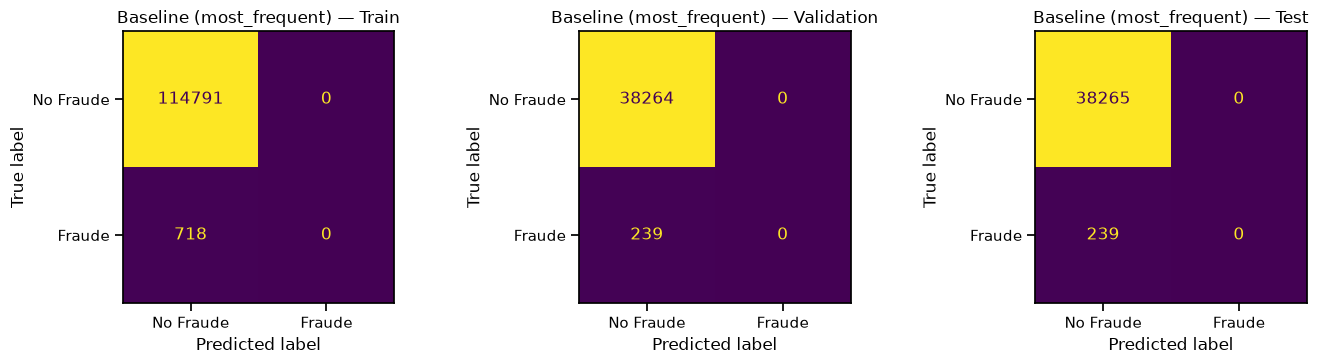

,Accuracy,Precision,Recall,F1,PR-AUC
Conjunto,,,,,
Train,0.9938,0.0000,0.0000,0.0000,0.0062
Validation,0.9938,0.0000,0.0000,0.0000,0.0062
Test,0.9938,0.0000,0.0000,0.0000,0.0062


In [7]:
baseline_mf = DummyClassifier(strategy='most_frequent', random_state=SEED).fit(X_train, y_train)
evaluar(baseline_mf, 'Baseline (most_frequent)')

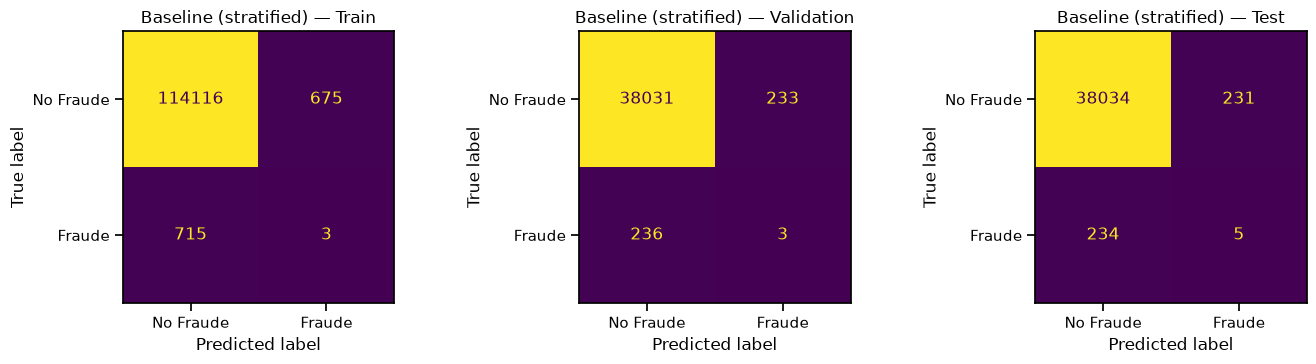

,Accuracy,Precision,Recall,F1,PR-AUC
Conjunto,,,,,
Train,0.9880,0.0044,0.0042,0.0043,0.0062
Validation,0.9878,0.0127,0.0126,0.0126,0.0063
Test,0.9879,0.0212,0.0209,0.0211,0.0065


In [8]:
baseline_st = DummyClassifier(strategy='stratified', random_state=SEED).fit(X_train, y_train)
evaluar(baseline_st, 'Baseline (stratified)')

en dólares            :  3.18% de las transacciones de train | tasa de fraude  9.29%
e-commerce            :  8.48% de las transacciones de train | tasa de fraude  5.04%
dólares y e-commerce  :  0.79% de las transacciones de train | tasa de fraude 21.93%
total                 :                                   tasa de fraude  0.62%


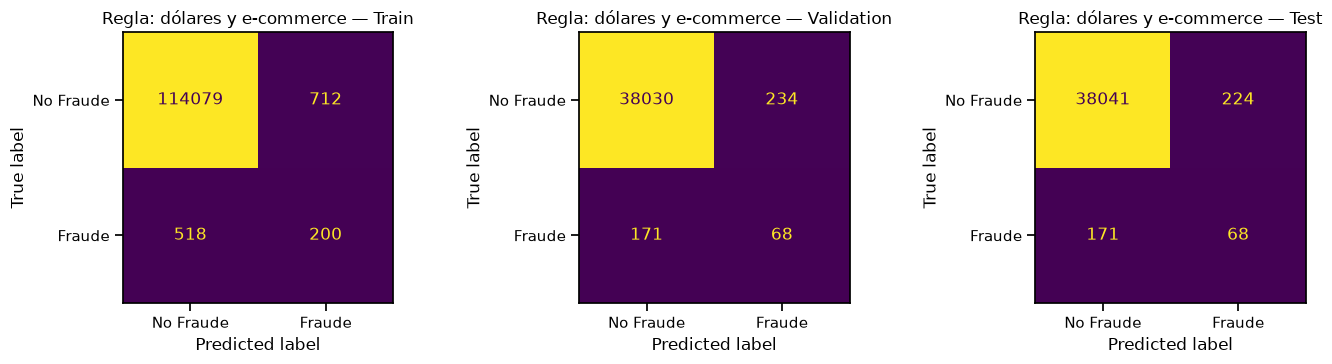

,Accuracy,Precision,Recall,F1,PR-AUC
Conjunto,,,,,
Train,0.9894,0.2193,0.2786,0.2454,NaN
Validation,0.9895,0.2252,0.2845,0.2514,NaN
Test,0.9897,0.2329,0.2845,0.2561,NaN


In [9]:
class ReglaNegocio:
    """Regla fija (no se ajusta con datos): fraude si la transacción es en dólares Y por e-commerce.
    Tiene predict/predict_proba para poder evaluarla con la misma función que los modelos."""
    def fit(self, X, y=None):
        return self
    def predict(self, X):
        return ((X['Trx_Moneda'] == 1) & (X['TipoTerminal_Agrupamiento_Compras y E-commerce'] == 1)).astype(int).values
    def predict_proba(self, X):
        p = self.predict(X)
        return np.column_stack([1 - p, p])

ecommerce = X_train['TipoTerminal_Agrupamiento_Compras y E-commerce'] == 1
dolares = X_train['Trx_Moneda'] == 1
for nombre, mascara in {'en dólares': dolares, 'e-commerce': ecommerce, 'dólares y e-commerce': dolares & ecommerce}.items():
    print(f"{nombre:22s}: {mascara.mean():6.2%} de las transacciones de train | tasa de fraude {y_train[mascara].mean():6.2%}")
print(f"{'total':22s}:                                   tasa de fraude {y_train.mean():6.2%}")

regla = ReglaNegocio()
res_regla = evaluar(regla, 'Regla: dólares y e-commerce')
# una regla no tiene score continuo: su PR-AUC no es comparable con el de un modelo
resultados[-1]['PR-AUC'] = np.nan
res_regla['PR-AUC'] = np.nan
display(res_regla)

**Conclusiones del baseline.** `most_frequent` obtiene un Accuracy de 0,9938 pero **Recall = 0, Precision = 0 y F1 = 0**: no detecta ni un solo fraude (la matriz de confusión sólo tiene valores en la columna "No Fraude"), y su PR-AUC (0,0062) es exactamente la tasa de fraude, el piso de esa métrica. Esto confirma que **el Accuracy es una métrica engañosa** acá. `stratified` acierta algunos fraudes por azar: su Precision y su Recall van de 0,0042–0,0044 en train a 0,0209–0,0212 en test, es decir, entre 3 y 5 aciertos sobre los fraudes de cada conjunto.

La **regla de negocio** ya hace algo útil sin entrenar nada. En train, las transacciones en dólares tienen una tasa de fraude de 9,29% y las de e-commerce de 5,04%; las que cumplen las dos condiciones a la vez (0,79% de las transacciones) llegan a 21,93%, unas 35 veces el promedio (0,62%). Marcándolas como fraude, la regla logra en validación Precision 0,2252, Recall 0,2845 y **F1 0,2514** (0,2561 en test): detecta poco más de un cuarto de los fraudes, y una de cada cuatro alertas es fraude. Como no aprende de los datos, rinde igual en los tres conjuntos. **Éste es el piso real** que un modelo tiene que superar para justificar su complejidad.

## 4. Modelos lineales
Los modelos lineales son sensibles a la escala de las variables, por lo que los envolvemos en un `Pipeline` con `StandardScaler` (el escalador se ajusta sólo con train y se aplica a val/test, evitando fuga de información). Para contrarrestar el desbalance usamos `class_weight='balanced'`, que pondera cada error de la clase "Fraude" con mucho más peso.

Modelos: **LogisticRegression** y **LinearSVC** (ambos con semilla fija).

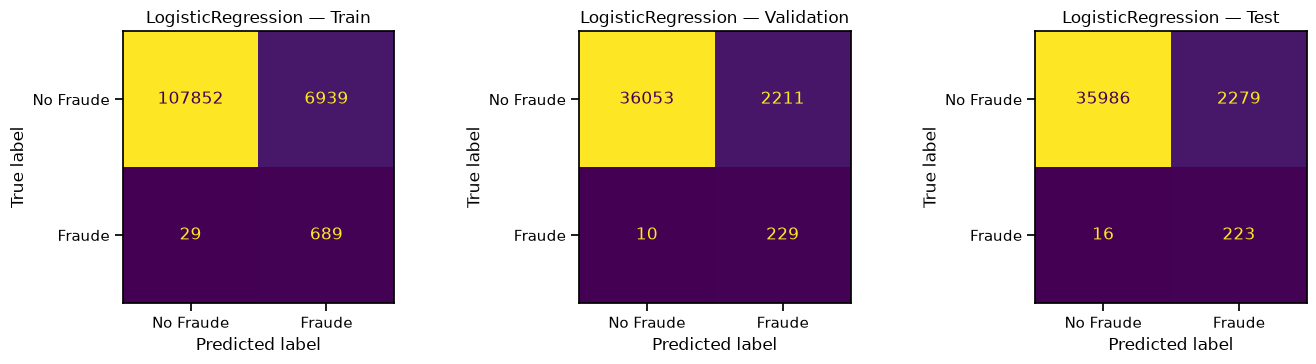

,Accuracy,Precision,Recall,F1,PR-AUC
Conjunto,,,,,
Train,0.9397,0.0903,0.9596,0.1651,0.3633
Validation,0.9423,0.0939,0.9582,0.1710,0.3967
Test,0.9404,0.0891,0.9331,0.1627,0.3949


In [10]:
lr = Pipeline([('scaler', StandardScaler()),
               ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED))])
lr.fit(X_train, y_train)
evaluar(lr, 'LogisticRegression')

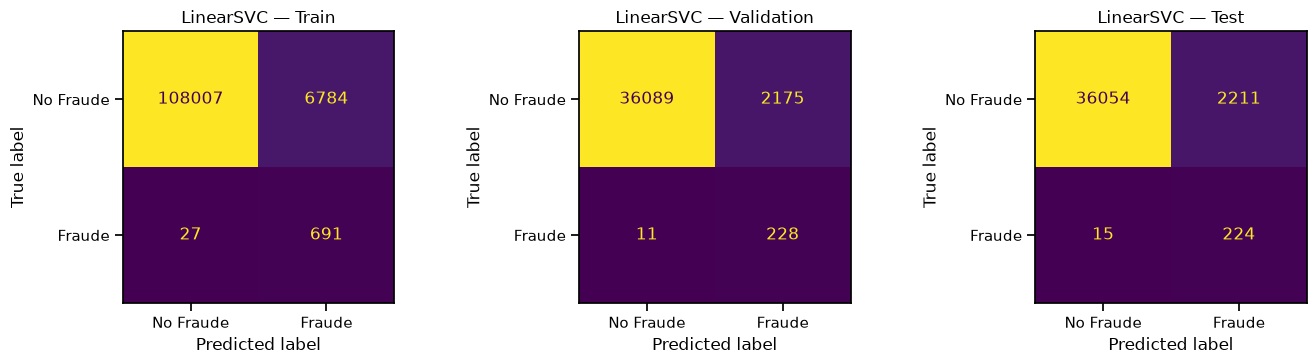

,Accuracy,Precision,Recall,F1,PR-AUC
Conjunto,,,,,
Train,0.9410,0.0924,0.9624,0.1687,0.3619
Validation,0.9432,0.0949,0.9540,0.1726,0.3990
Test,0.9422,0.0920,0.9372,0.1675,0.3890


In [11]:
svc = Pipeline([('scaler', StandardScaler()),
                ('clf', LinearSVC(class_weight='balanced', max_iter=5000, random_state=SEED))])
svc.fit(X_train, y_train)
evaluar(svc, 'LinearSVC')

**Conclusiones modelos lineales.** Los dos modelos lineales dan resultados casi idénticos. En validación, LogisticRegression logra Recall 0,9582 con Precision 0,0939 (F1 0,1710) y LinearSVC Recall 0,9540 con Precision 0,0949 (F1 0,1726). Con `class_weight='balanced'` se vuelven muy agresivos con la clase positiva: detectan casi todos los fraudes, pero generan unas 10 alertas por cada fraude real, y por eso **su F1 queda por debajo del de la regla de negocio (0,2514)**. No hay sobreajuste (train y validación dan prácticamente lo mismo), y la Accuracy baja respecto del baseline (0,94 contra 0,99), algo esperable: es el precio de alertar más.

Pero el F1 con umbral 0,5 no cuenta toda la historia. Su **PR-AUC** (0,3967 y 0,3990) está muy por encima de la tasa de fraude (0,006): los dos modelos *ordenan* razonablemente bien las transacciones por riesgo, y lo que falla es el punto de corte. En la sección 5.2 se ve que, con el mismo recall que la regla, los lineales logran bastante más precisión.

## 5. Modelos basados en árboles
Los árboles no requieren escalar, capturan **relaciones no lineales e interacciones** (por ejemplo, "importe alto + canal no presencial + cliente nuevo") y son robustos a outliers: justo lo que describe nuestro problema. Entrenamos **cuatro** (se pedía al menos dos), con parámetros por defecto salvo el manejo del desbalance:
- `DecisionTreeClassifier` (`class_weight='balanced'`),
- `RandomForestClassifier` (`class_weight='balanced_subsample'`),
- `HistGradientBoostingClassifier` (por defecto, sin pesos de clase; admite `class_weight` y lo exploramos en la búsqueda de hiperparámetros),
- `XGBClassifier` (**XGBoost**, el boosting que el TP2 recomendó para esta etapa), con una configuración "de manual".

Además, entrenamos un **árbol de profundidad 3** que no compite en desempeño, pero que se puede leer entero y traducir a reglas de negocio (sección 5.1).

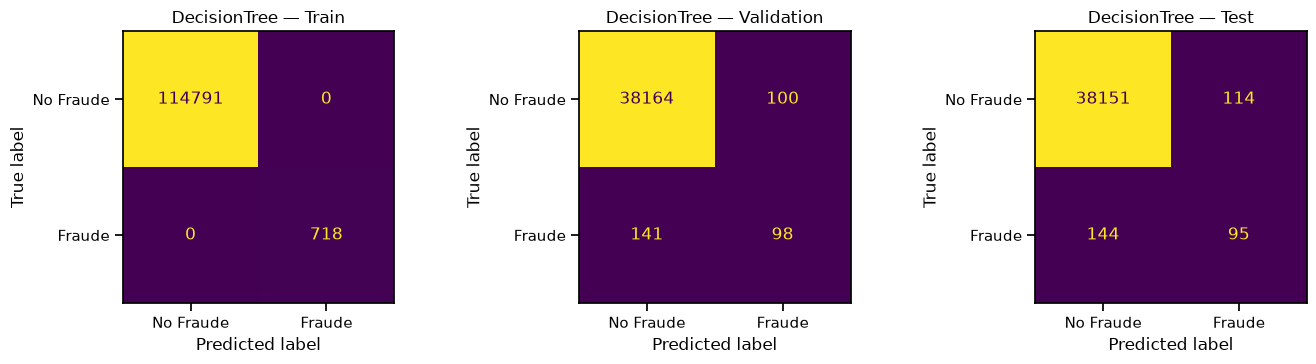

,Accuracy,Precision,Recall,F1,PR-AUC
Conjunto,,,,,
Train,1.0000,1.0000,1.0000,1.0000,1.0000
Validation,0.9937,0.4949,0.4100,0.4485,0.2066
Test,0.9933,0.4545,0.3975,0.4241,0.1844


In [12]:
dt = DecisionTreeClassifier(class_weight='balanced', random_state=SEED).fit(X_train, y_train)
evaluar(dt, 'DecisionTree')

### 5.1 Un árbol poco profundo, traducido a reglas de negocio

Un árbol de profundidad 3 pierde capacidad predictiva pero se **puede leer entero**. Lo entrenamos **sin los componentes PCA** (son combinaciones de varias variables y no se traducen a una pregunta de negocio) y lo dibujamos en un formato pensado para negocio: cada caja dice cuántas transacciones de train llegaron hasta ahí y **qué porcentaje es fraude** (más naranja = más riesgo); en cada pregunta, la rama izquierda es "No" y la derecha "Sí".

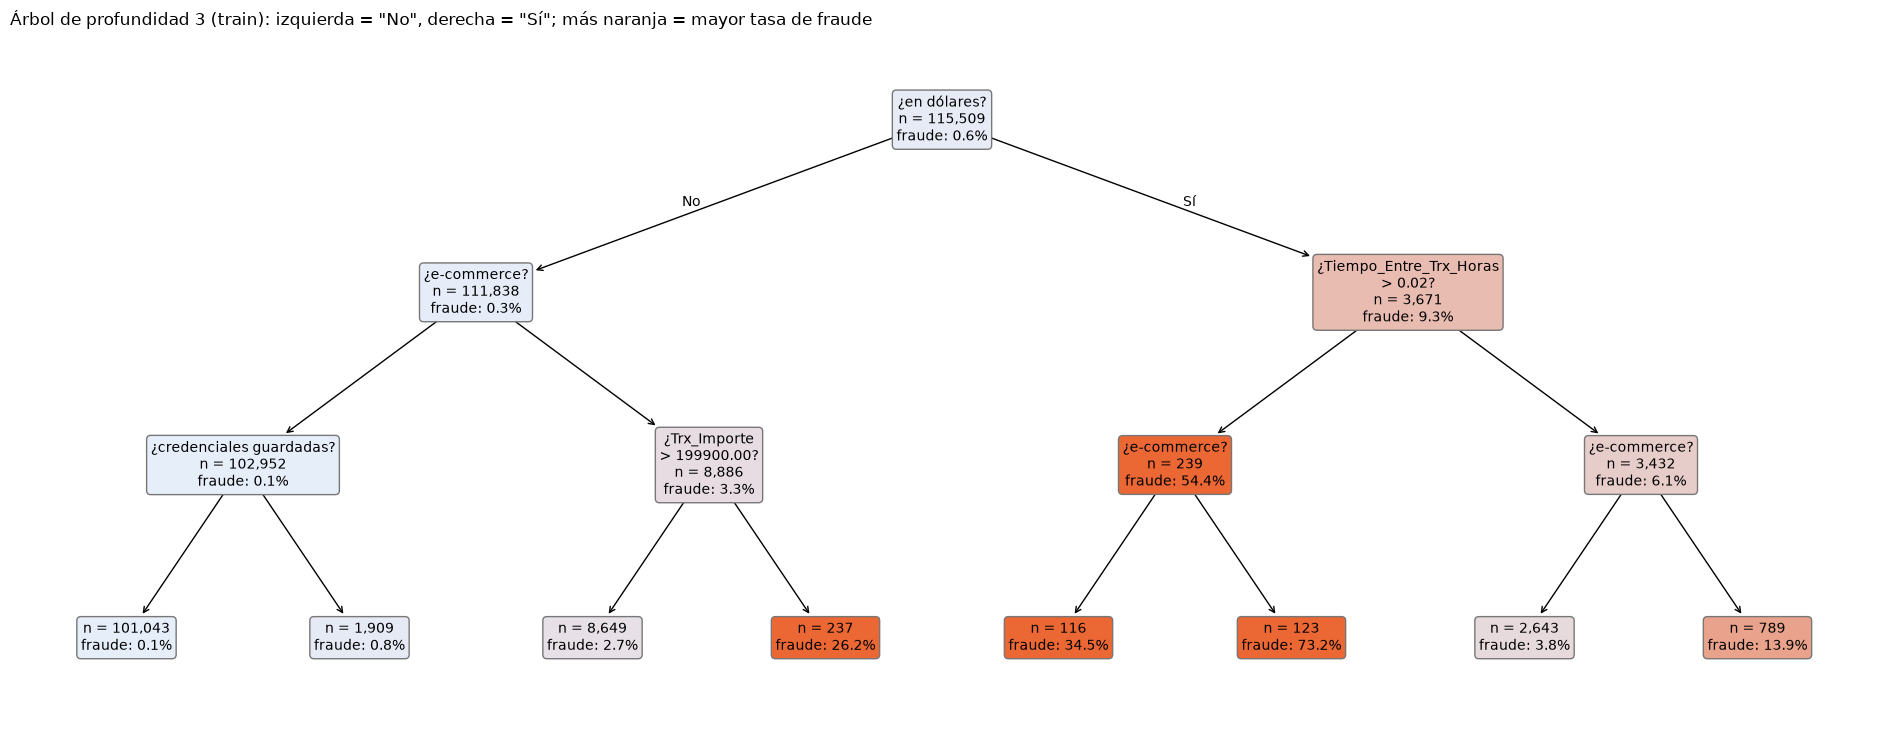

,regla (hoja),transacciones,fraudes,tasa de fraude (%)
0,en dólares Y Tiempo_Entre_Trx_Horas <= 0.02 Y e-commerce,123,90,73.1700
1,en dólares Y Tiempo_Entre_Trx_Horas <= 0.02 Y NO e-commerce,116,40,34.4800
2,NO en dólares Y e-commerce Y Trx_Importe > 199900.00,237,62,26.1600
3,en dólares Y Tiempo_Entre_Trx_Horas > 0.02 Y e-commerce,789,110,13.9400
4,en dólares Y Tiempo_Entre_Trx_Horas > 0.02 Y NO e-commerce,2643,101,3.8200
5,NO en dólares Y e-commerce Y Trx_Importe <= 199900.00,8649,232,2.6800
6,NO en dólares Y NO e-commerce Y credenciales guardadas,1909,16,0.8400
7,NO en dólares Y NO e-commerce Y NO credenciales guardadas,101043,67,0.0700


In [13]:
cols_legibles = [c for c in X_train.columns if not c.startswith('PCA_')]
BINARIAS = [c for c in cols_legibles if set(X_train[c].unique()) <= {0, 1}]
ALIAS = {'Trx_Moneda': 'en dólares', 'Presencia_Cliente': 'cliente presente', 'Es_Outlier_Importe': 'importe atípico',
         'TipoTerminal_Agrupamiento_Compras y E-commerce': 'e-commerce',
         'TipoTerminal_Agrupamiento_Credenciales Guardadas (Suscripciones)': 'credenciales guardadas',
         'TipoTerminal_Agrupamiento_Pagos de Servicios y Web': 'pago de servicios web',
         'Categoria_Rubro_SIN_RUBRO': 'sin rubro', 'Categoria_Rubro_OTROS_RUBROS': 'rubro otros',
         'Categoria_Rubro_Servicios Varios': 'rubro servicios varios'}

def pregunta(c, thr):
    return f"¿{ALIAS.get(c, c)}?" if c in BINARIAS else f"¿{c}\n> {thr:.2f}?"

def condicion(c, thr, izquierda):
    if c in BINARIAS:
        return ('NO ' if izquierda else '') + ALIAS.get(c, c)
    return f"{c} {'<=' if izquierda else '>'} {thr:.2f}"

def color_riesgo(tasa, tope=0.25):
    t = min(1.0, tasa / tope)
    inicio, fin = np.array(mcolors.to_rgb('#e6eefb')), np.array(mcolors.to_rgb(NARANJA))
    return tuple(inicio + (fin - inicio) * t)

arbol_legible = DecisionTreeClassifier(max_depth=3, min_samples_leaf=100, random_state=SEED)
arbol_legible.fit(X_train[cols_legibles], y_train)
t = arbol_legible.tree_

fig, ax = plt.subplots(figsize=(19, 7.5))
anots = plot_tree(arbol_legible, feature_names=cols_legibles, filled=True, impurity=False, rounded=True, fontsize=10, ax=ax)
for a in anots:   # plot_tree rotula las ramas de la raíz con True/False: en nuestro formato, izquierda = No y derecha = Sí
    if a.get_text().strip() == 'True':
        a.set_text('No  ')
    elif a.get_text().strip() == 'False':
        a.set_text('  Sí')
anots = [a for a in anots if a.get_text().strip() not in ('No', 'Sí')]
preorden = []
def recorrer(n):
    preorden.append(n)
    if t.children_left[n] != -1:
        recorrer(t.children_left[n]); recorrer(t.children_right[n])
recorrer(0)
assert len(preorden) == len(anots)
for nodo, ann in zip(preorden, anots):
    v = t.value[nodo][0]; tasa = v[1] / v.sum()
    cabecera = pregunta(cols_legibles[t.feature[nodo]], t.threshold[nodo]) + "\n" if t.children_left[nodo] != -1 else ""
    ann.set_text(f"{cabecera}n = {int(t.n_node_samples[nodo]):,}\nfraude: {tasa:.1%}")
    ann.get_bbox_patch().set_facecolor(color_riesgo(tasa))
    ann.get_bbox_patch().set_edgecolor('#777777')
ax.set_title('Árbol de profundidad 3 (train): izquierda = "No", derecha = "Sí"; más naranja = mayor tasa de fraude', loc='left')
plt.tight_layout(); plt.show()

# Las 8 hojas como reglas de negocio
filas = []
def reglas(nodo, camino):
    if t.children_left[nodo] == -1:
        v = t.value[nodo][0]; n = int(t.n_node_samples[nodo]); tasa = v[1] / v.sum()
        filas.append({'regla (hoja)': ' Y '.join(camino), 'transacciones': n, 'fraudes': int(round(tasa * n)), 'tasa de fraude (%)': tasa * 100})
        return
    c, thr = cols_legibles[t.feature[nodo]], t.threshold[nodo]
    reglas(t.children_left[nodo], camino + [condicion(c, thr, True)])
    reglas(t.children_right[nodo], camino + [condicion(c, thr, False)])
reglas(0, [])
pd.set_option('display.max_colwidth', 120)
display(pd.DataFrame(filas).sort_values('tasa de fraude (%)', ascending=False).reset_index(drop=True).round(2))

**Comentario.** El árbol se lee de arriba hacia abajo como un protocolo de revisión. La primera pregunta es si la operación es **en dólares**: en train, las 111.838 transacciones en pesos tienen una tasa de fraude de 0,3% y las 3.671 en dólares de 9,3%. Dentro de los dólares, lo que más separa es el **tiempo desde la transacción anterior**: si pasaron 0,02 horas o menos (72 segundos, una *ráfaga* de operaciones), la tasa sube a 54,4%. La hoja más riesgosa es **"en dólares, en ráfaga y por e-commerce": 123 transacciones con 73,17% de fraude** (90 fraudes). En pesos, la señal más fuerte es e-commerce con un importe mayor a 199.900: 237 transacciones con 26,16% de fraude.

Dos lecturas para el negocio. Primero, el árbol encuentra una señal que nuestra regla no tenía: la **ráfaga**, operaciones en dólares separadas por 72 segundos o menos. Segundo, deja a la vista la parte difícil del problema: la hoja "pesos, e-commerce, importe ≤ 199.900" reúne 232 fraudes, más que cualquier otra hoja, pero diluidos en 8.649 transacciones (2,68%), y ninguna regla simple los aísla. Este árbol sirve para **explicar**, no para competir: para detectar ese fraude hacen falta los modelos que siguen.

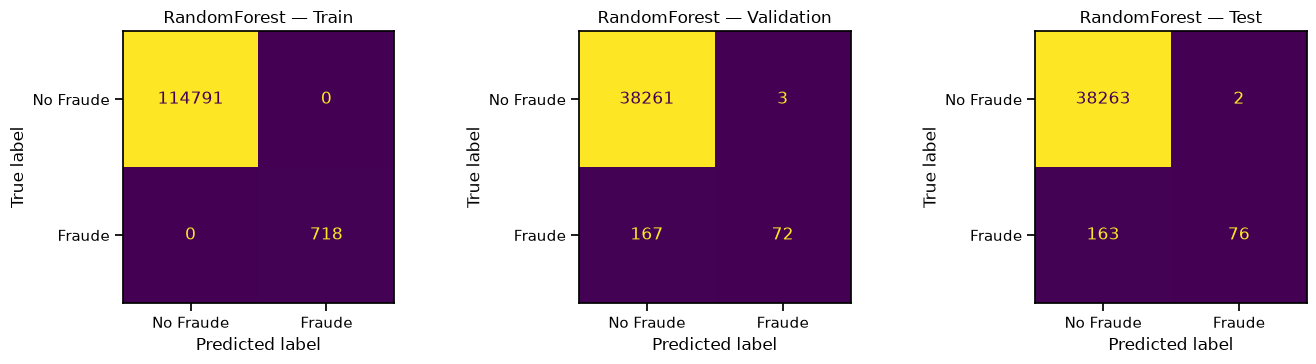

,Accuracy,Precision,Recall,F1,PR-AUC
Conjunto,,,,,
Train,1.0000,1.0000,1.0000,1.0000,1.0000
Validation,0.9956,0.9600,0.3013,0.4586,0.6790
Test,0.9957,0.9744,0.3180,0.4795,0.6998


In [14]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced_subsample', n_jobs=-1, random_state=SEED).fit(X_train, y_train)
evaluar(rf, 'RandomForest')

Iteraciones de boosting realizadas: 11 de 100


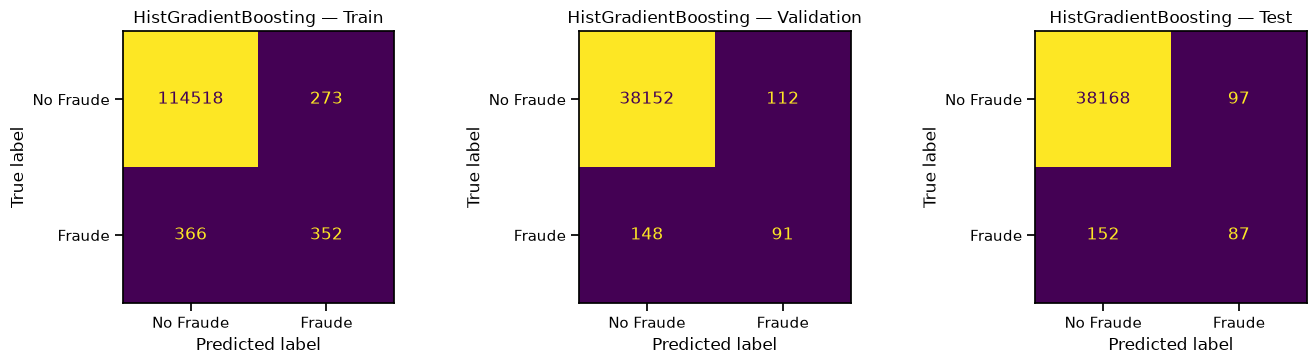

,Accuracy,Precision,Recall,F1,PR-AUC
Conjunto,,,,,
Train,0.9945,0.5632,0.4903,0.5242,0.5479
Validation,0.9932,0.4483,0.3808,0.4118,0.3540
Test,0.9935,0.4728,0.3640,0.4113,0.3580


In [15]:
gb = HistGradientBoostingClassifier(random_state=SEED).fit(X_train, y_train)
# Por defecto early_stopping='auto': con más de 10.000 filas aparta un 10% de train y corta cuando la pérdida deja de mejorar
print(f'Iteraciones de boosting realizadas: {gb.n_iter_} de {gb.max_iter}')
evaluar(gb, 'HistGradientBoosting')

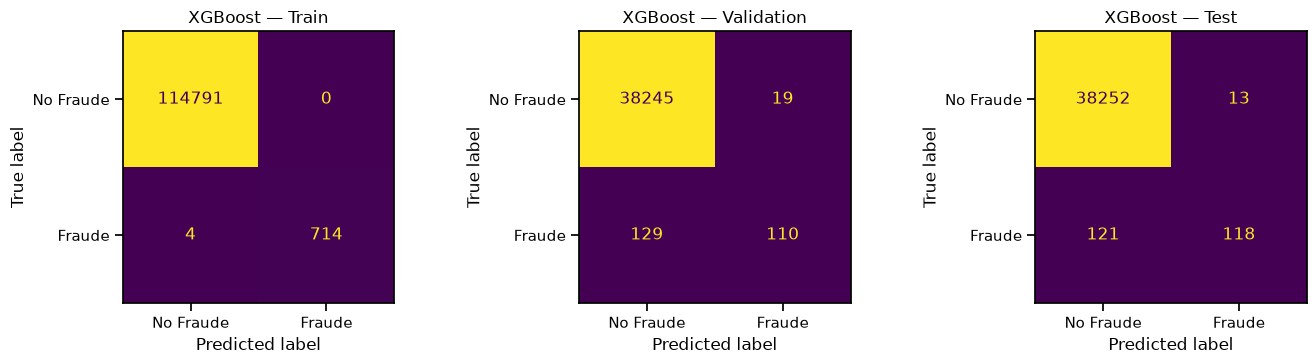

,Accuracy,Precision,Recall,F1,PR-AUC
Conjunto,,,,,
Train,1.0000,1.0000,0.9944,0.9972,1.0000
Validation,0.9962,0.8527,0.4603,0.5978,0.7201
Test,0.9965,0.9008,0.4937,0.6378,0.7530


In [16]:
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
                    tree_method='hist', eval_metric='aucpr', n_jobs=XGB_JOBS, random_state=SEED).fit(X_train, y_train)
evaluar(xgb, 'XGBoost')

**Conclusiones modelos de árboles.**
- **DecisionTree** sin límite de profundidad **sobreajusta**: F1 y PR-AUC de 1,0000 en train contra F1 0,4485 y PR-AUC 0,2066 en validación.
- **RandomForest** también memoriza el train (F1 1,0000), pero generaliza mucho mejor: PR-AUC de 0,6790 en validación. Con el umbral 0,5 es muy conservador: Precision 0,9600 pero Recall 0,3013, es decir, detecta menos de un tercio de los fraudes.
- **HistGradientBoosting** rinde por debajo de lo esperable (PR-AUC 0,3540). Con los parámetros por defecto, el *early stopping* automático cortó el entrenamiento en 11 de las 100 iteraciones, así que el modelo quedó con muy pocos árboles: su resultado dice más de esa configuración por defecto que del método.
- **XGBoost** es el mejor: PR-AUC de 0,7201 en validación y F1 de 0,5978 (Precision 0,8527, Recall 0,4603), aunque también se aprende el train casi de memoria (F1 0,9972).

Los ensambles superan a los lineales porque modelan interacciones y no linealidades, como las que muestra el árbol de la sección 5.1. Y con el umbral 0,5 todos los árboles detectan menos de la mitad de los fraudes: eso no es un defecto de los modelos sino del punto de corte, que ajustamos en la sección 6.3.

### 5.2 Tabla comparativa de todos los modelos (parámetros por defecto)

,Accuracy,Precision,Recall,F1,PR-AUC
Modelo,,,,,
XGBoost,0.9962,0.8527,0.4603,0.5978,0.7201
RandomForest,0.9956,0.9600,0.3013,0.4586,0.6790
LinearSVC,0.9432,0.0949,0.9540,0.1726,0.3990
LogisticRegression,0.9423,0.0939,0.9582,0.1710,0.3967
HistGradientBoosting,0.9932,0.4483,0.3808,0.4118,0.3540
DecisionTree,0.9937,0.4949,0.4100,0.4485,0.2066
Baseline (stratified),0.9878,0.0127,0.0126,0.0126,0.0063
Baseline (most_frequent),0.9938,0.0000,0.0000,0.0000,0.0062
Regla: dólares y e-commerce,0.9895,0.2252,0.2845,0.2514,NaN


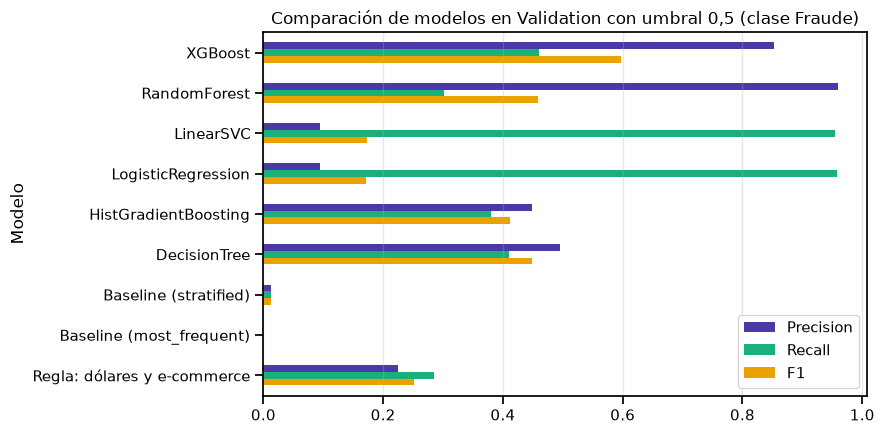

Conjunto,Train,Validation,Test,Gap Train-Val
Modelo,,,,
XGBoost,0.9972,0.5978,0.6378,0.3994
RandomForest,1.0000,0.4586,0.4795,0.5414
DecisionTree,1.0000,0.4485,0.4241,0.5515
HistGradientBoosting,0.5242,0.4118,0.4113,0.1124
Regla: dólares y e-commerce,0.2454,0.2514,0.2561,-0.0060
LinearSVC,0.1687,0.1726,0.1675,-0.0039
LogisticRegression,0.1651,0.1710,0.1627,-0.0059
Baseline (stratified),0.0043,0.0126,0.0211,-0.0083
Baseline (most_frequent),0.0000,0.0000,0.0000,0.0000


In [17]:
comp = pd.concat(resultados, ignore_index=True)
tabla_val = comp[comp['Conjunto']=='Validation'].set_index('Modelo').drop(columns='Conjunto').sort_values('PR-AUC', ascending=False)
display(tabla_val)

fig, ax = plt.subplots(figsize=(9, 4.5))
tabla_val[['Precision','Recall','F1']].plot(kind='barh', ax=ax, color=['#4a3aa7', '#1baf7a', '#eda100'])
ax.set_title('Comparación de modelos en Validation con umbral 0,5 (clase Fraude)'); ax.invert_yaxis()
ax.grid(axis='x', alpha=.3)
plt.tight_layout(); plt.show()

# Diagnóstico de sobreajuste: F1 train vs validation
sobre = comp.pivot(index='Modelo', columns='Conjunto', values='F1')[['Train','Validation','Test']]
sobre['Gap Train-Val'] = sobre['Train'] - sobre['Validation']
sobre.sort_values('Validation', ascending=False)

Las barras de arriba usan el umbral de 0,5, que deja a cada modelo en un punto de operación distinto. Para compararlos de forma pareja miramos las **curvas Precision-Recall** en validación: muestran todos los puntos de operación posibles de cada modelo, y la regla de negocio aparece como un único punto.

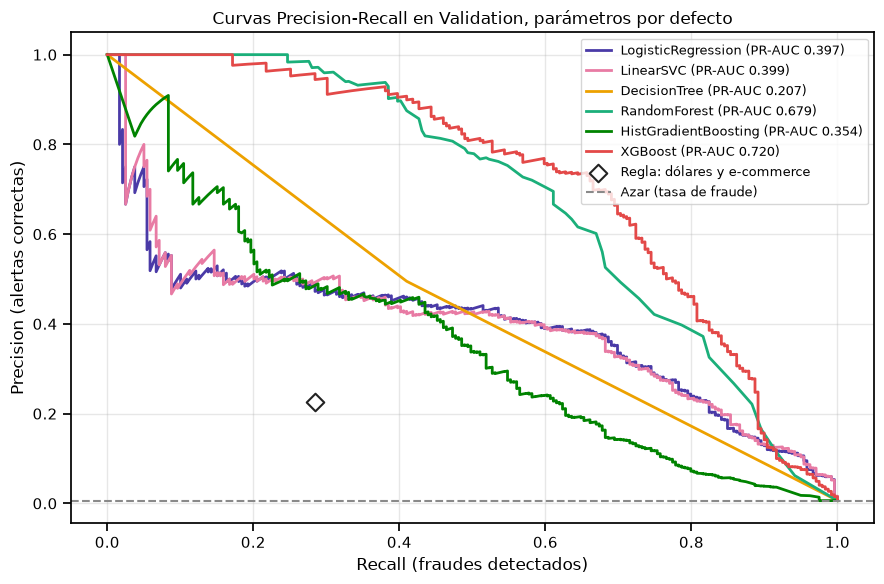

In [18]:
modelos_base = {'LogisticRegression': lr, 'LinearSVC': svc, 'DecisionTree': dt,
                'RandomForest': rf, 'HistGradientBoosting': gb, 'XGBoost': xgb}

fig, ax = plt.subplots(figsize=(9, 6))
for nombre, modelo in modelos_base.items():
    s = get_score(modelo, X_val)
    p, r, _ = precision_recall_curve(y_val, s)
    ax.plot(r, p, color=COLOR_MODELO[nombre], lw=2, label=f'{nombre} (PR-AUC {average_precision_score(y_val, s):.3f})')
pr_regla = regla.predict(X_val)
ax.scatter(recall_score(y_val, pr_regla), precision_score(y_val, pr_regla), marker='D', s=80, color='white',
           edgecolor='#222222', linewidth=1.5, zorder=5, label='Regla: dólares y e-commerce')
ax.axhline(y_val.mean(), ls='--', color=GRIS, label='Azar (tasa de fraude)')
ax.set_xlabel('Recall (fraudes detectados)'); ax.set_ylabel('Precision (alertas correctas)')
ax.set_title('Curvas Precision-Recall en Validation, parámetros por defecto')
ax.legend(loc='upper right', fontsize=9); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Comentario.** Las curvas ordenan a los modelos con más claridad que las barras con umbral 0,5. **XGBoost (PR-AUC 0,720) y Random Forest (0,679)** quedan por encima del resto en casi todo el rango, y XGBoost es el que mejor se sostiene cuando se le pide detectar más de la mitad de los fraudes, que es la zona donde opera un sistema de alertas. Los dos lineales (0,397 y 0,399) son prácticamente indistinguibles; HistGradientBoosting (0,354) cae por debajo de ellos a partir de un recall de ~0,4; y el árbol sin restricciones (0,207) es casi una recta, porque tiene un único punto de operación útil. La tabla de sobreajuste lo confirma: el gap Train–Val de F1 es de 0,55 en el árbol, 0,54 en Random Forest y 0,40 en XGBoost, y prácticamente 0 en los lineales y en la regla.

El dato más interesante es la **regla de negocio**: su punto queda **por debajo de todas las curvas**. Con el mismo recall que ella (~0,28), hasta los modelos lineales logran una precisión de alrededor de 0,5, contra 0,23 de la regla. Es decir, aunque con umbral 0,5 los lineales tienen peor F1 que la regla, **cualquier modelo la supera si se elige bien el umbral**. Por eso comparamos y ajustamos con PR-AUC.

In [19]:
candidatos = ['LogisticRegression', 'LinearSVC', 'DecisionTree', 'RandomForest', 'HistGradientBoosting', 'XGBoost']
rank = tabla_val.loc[candidatos].sort_values('PR-AUC', ascending=False)
top2 = list(rank.index[:2])
print('Ranking por PR-AUC en validación:'); print(rank['PR-AUC'].round(4).to_string())
print('\nMejor modelo:', top2[0], '| Segundo mejor:', top2[1])

Ranking por PR-AUC en validación:
Modelo
XGBoost                0.7201
RandomForest           0.6790
LinearSVC              0.3990
LogisticRegression     0.3967
HistGradientBoosting   0.3540
DecisionTree           0.2066

Mejor modelo: XGBoost | Segundo mejor: RandomForest


**Comentario.** Ordenados por PR-AUC en validación, los dos mejores son **XGBoost (0,7201) y Random Forest (0,6790)**, muy lejos del tercero (LinearSVC, 0,3990): son los que llevamos a la búsqueda de hiperparámetros. Elegimos **en validación y no en test** para que el test siga siendo una estimación honesta del desempeño final.

Vale la pena mirar el caso del árbol de decisión: por F1 con umbral 0,5 es el tercero (0,4485), pero por PR-AUC es el último (0,2066). Su F1 sale de un único punto de operación que justo cae bien, no de que ordene bien las transacciones por riesgo. Es un ejemplo concreto de por qué no elegimos los modelos con F1 a umbral fijo.

## 6. Ajuste de hiperparámetros (GridSearch + k-fold)

### 6.0 ¿Qué métrica optimizar en la búsqueda?

En una primera versión de este TP la búsqueda optimizaba **F1** (con el umbral de 0,5). La configuración de Random Forest que eligió así fue `max_depth=20`, `min_samples_leaf=5` con `class_weight='balanced_subsample'`. Antes de seguir comparamos esa configuración contra el Random Forest por defecto **solo en validación**, con dos medidas: el F1 con umbral 0,5 y la calidad del ranking (PR-AUC, más el mejor F1 que se puede lograr moviendo el umbral).

In [20]:
rf_cfg_f1 = RandomForestClassifier(n_estimators=100, class_weight='balanced_subsample', max_depth=20, min_samples_leaf=5,
                                   n_jobs=-1, random_state=SEED).fit(X_train, y_train)
filas = []
for nombre, modelo in {'RandomForest (por defecto)': rf, 'RandomForest (config. elegida optimizando F1)': rf_cfg_f1}.items():
    s = get_score(modelo, X_val)
    u = umbral_max_f1(y_val, s)
    filas.append({'Modelo': nombre, 'F1 val (umbral 0,5)': f1_score(y_val, modelo.predict(X_val)),   # predict = umbral 0,5, igual que evaluar()
                  'PR-AUC val': average_precision_score(y_val, s),
                  'Mejor umbral en val': u, 'F1 val (mejor umbral)': f1_score(y_val, s >= u)})
display(pd.DataFrame(filas).set_index('Modelo'))

,"F1 val (umbral 0,5)",PR-AUC val,Mejor umbral en val,F1 val (mejor umbral)
Modelo,,,,
RandomForest (por defecto),0.4586,0.6790,0.1900,0.6503
RandomForest (config. elegida optimizando F1),0.6115,0.6379,0.4825,0.6176


**Comentario.** La configuración que había elegido la búsqueda por F1 sube el F1 con umbral 0,5 de 0,4586 a 0,6115, pero **empeora el modelo**: su PR-AUC baja de 0,6790 a 0,6379. Lo que cambió fue la escala de sus probabilidades: su mejor umbral es 0,4825, casi 0,5, mientras que el del bosque por defecto es 0,19. Con el umbral fijo en 0,5, eso la favorece; pero cuando a cada versión se le elige su mejor umbral, **el Random Forest por defecto gana** (F1 0,6503 contra 0,6176). La búsqueda por F1 había premiado un corrimiento del punto de operación, no un mejor modelo. Por eso, en la búsqueda que sigue optimizamos **PR-AUC** y dejamos la elección del umbral para la sección 6.3.

(Los F1 con "mejor umbral" están medidos sobre la misma validación con la que se eligió el umbral, así que son algo optimistas, pero para las dos versiones por igual: sirven para compararlas entre sí.)

### 6.1 Búsqueda con validación cruzada sobre los dos mejores modelos

Para los **dos mejores modelos** de la sección 5 hacemos una búsqueda exhaustiva (`GridSearchCV`) con **validación cruzada estratificada de 3 folds** (`StratifiedKFold`, que mantiene la proporción de fraude en cada fold), optimizando **PR-AUC** (`scoring='average_precision'`). La búsqueda se hace **sólo sobre Train**: validación queda para comparar el modelo tuneado contra el de parámetros por defecto y para elegir el umbral, y test sigue sin tocarse. Cada grilla ajusta **al menos 3 hiperparámetros**.

> ⏱ La búsqueda puede tardar varios minutos en Colab.

In [21]:
def base_model(nombre):
    if nombre == 'LogisticRegression':
        return Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=SEED))])
    if nombre == 'LinearSVC':
        return Pipeline([('scaler', StandardScaler()), ('clf', LinearSVC(max_iter=5000, random_state=SEED))])
    if nombre == 'DecisionTree':
        return DecisionTreeClassifier(random_state=SEED)
    if nombre == 'RandomForest':
        return RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED)
    if nombre == 'HistGradientBoosting':
        return HistGradientBoostingClassifier(random_state=SEED)
    if nombre == 'XGBoost':
        return XGBClassifier(n_estimators=300, subsample=0.8, colsample_bytree=0.8, tree_method='hist',
                             eval_metric='aucpr', n_jobs=XGB_JOBS, random_state=SEED)

grillas = {
    'LogisticRegression':   {'clf__C': [0.01, 0.1, 1, 10], 'clf__class_weight': ['balanced', None, {0:1, 1:10}],
                             'clf__solver': ['lbfgs', 'liblinear']},
    'LinearSVC':            {'clf__C': [0.01, 0.1, 1], 'clf__class_weight': ['balanced', None, {0:1, 1:10}],
                             'clf__loss': ['hinge', 'squared_hinge']},
    'DecisionTree':         {'max_depth': [5, 10, 20], 'min_samples_leaf': [1, 10, 50],
                             'class_weight': ['balanced', None]},
    'RandomForest':         {'max_depth': [10, 20, None], 'min_samples_leaf': [1, 5],
                             'class_weight': ['balanced_subsample', None]},
    'HistGradientBoosting': {'max_iter': [100, 200], 'learning_rate': [0.05, 0.1],
                             'max_leaf_nodes': [15, 31], 'class_weight': [None, 'balanced']},
    'XGBoost':              {'max_depth': [4, 6, 8], 'learning_rate': [0.05, 0.1],
                             'scale_pos_weight': [1, 10]},
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
mejores = {}
for nombre in top2:
    print(f'\n=== GridSearchCV: {nombre} ===')
    gs = GridSearchCV(base_model(nombre), grillas[nombre], scoring='average_precision', cv=cv, n_jobs=-1, refit=True, verbose=1)
    gs.fit(X_train, y_train)
    mejores[nombre] = gs
    print('Mejores hiperparámetros:', gs.best_params_)
    print(f'PR-AUC medio CV (train): {gs.best_score_:.4f}')


=== GridSearchCV: XGBoost ===
Fitting 3 folds for each of 12 candidates, totalling 36 fits


Mejores hiperparámetros: {'learning_rate': 0.1, 'max_depth': 8, 'scale_pos_weight': 10}
PR-AUC medio CV (train): 0.6796

=== GridSearchCV: RandomForest ===
Fitting 3 folds for each of 12 candidates, totalling 36 fits


Mejores hiperparámetros: {'class_weight': None, 'max_depth': 20, 'min_samples_leaf': 1}
PR-AUC medio CV (train): 0.6394


In [22]:
# Detalle de la búsqueda: los 5 mejores candidatos de cada modelo
for nombre, gs in mejores.items():
    r = pd.DataFrame(gs.cv_results_)
    cols = ['rank_test_score', 'mean_test_score', 'std_test_score'] + [c for c in r.columns if c.startswith('param_')]
    print(f'--- {nombre} ---')
    display(r.sort_values('rank_test_score')[cols].head(5))

--- XGBoost ---


,rank_test_score,mean_test_score,std_test_score,param_learning_rate,param_max_depth,param_scale_pos_weight
11,1,0.6796,0.0120,0.1000,8,10
9,2,0.6792,0.0175,0.1000,6,10
10,3,0.6768,0.0212,0.1000,8,1
5,4,0.6736,0.0186,0.0500,8,10
4,5,0.6712,0.0141,0.0500,8,1


--- RandomForest ---


,rank_test_score,mean_test_score,std_test_score,param_class_weight,param_max_depth,param_min_samples_leaf
8,1,0.6394,0.0229,None,20,1
10,2,0.6386,0.0246,None,None,1
4,3,0.6215,0.0164,balanced_subsample,None,1
5,4,0.5818,0.0183,balanced_subsample,None,5
9,5,0.5786,0.0229,None,20,5


**Lectura de la búsqueda.** En los dos modelos, las mejores configuraciones quedan muy cerca entre sí. Para **XGBoost**, la mejor combinación es `max_depth=8`, `learning_rate=0.1` y `scale_pos_weight=10`, con un PR-AUC de 0,6796 en validación cruzada; la segunda (`max_depth=6`) da 0,6792 y la tercera (sin pesos de clase) 0,6768, diferencias muy por debajo del desvío entre folds (de 0,012 a 0,021). Para **Random Forest** gana `max_depth=20`, `min_samples_leaf=1` y **sin pesos de clase** (0,6394, desvío 0,0229), prácticamente empatada con la misma configuración sin límite de profundidad (0,6386).

Dos cosas para notar: (1) optimizando PR-AUC, el Random Forest prefiere **no** usar `class_weight`, lo contrario de lo que había elegido la búsqueda por F1; y (2) `max_depth=8` es el valor más alto de la grilla de XGBoost, así que podría haber margen probando árboles más profundos.

### 6.2 Por defecto vs. tuneado: ¿mejoró el modelo o sólo el umbral?

Para que la comparación sea pareja, a cada versión (por defecto y tuneada) le elegimos **su propio umbral** en validación (el que maximiza su F1) y recién con ese umbral miramos el F1. Así separamos lo que aporta el ajuste de hiperparámetros (mejor ranking, PR-AUC) de lo que aporta mover el punto de corte. El modelo final es el de **mayor PR-AUC en validación**: el test no participa de la elección.

,PR-AUC val,PR-AUC test,Umbral (elegido en val),F1 val,F1 test
Modelo,,,,,
XGBoost (por defecto),0.7201,0.7530,0.1631,0.6947,0.7018
XGBoost (tuneado),0.7396,0.7579,0.1780,0.7158,0.7124
RandomForest (por defecto),0.6790,0.6998,0.1900,0.6503,0.6623
RandomForest (tuneado),0.6963,0.7395,0.2291,0.6491,0.6696


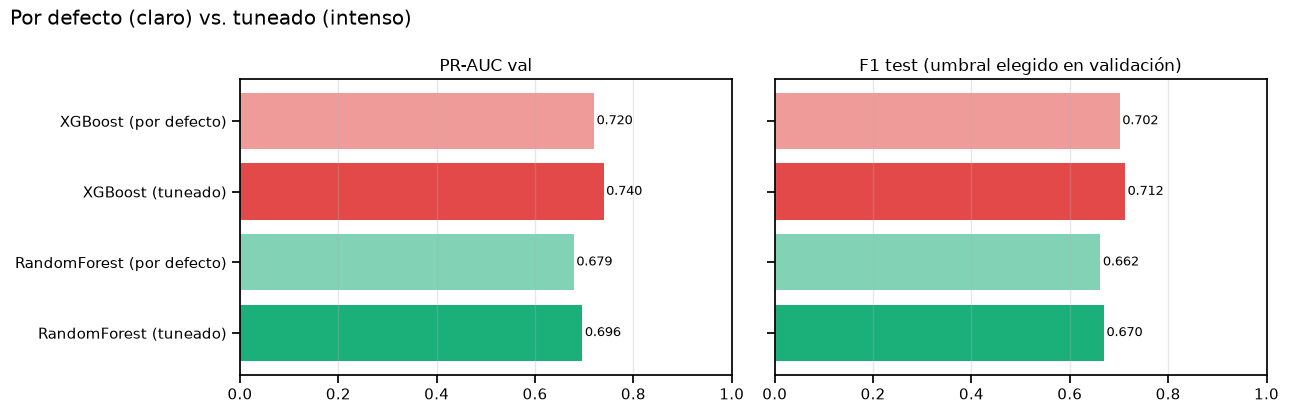

==> Modelo final: XGBoost (tuneado)
    Hiperparámetros: {'learning_rate': 0.1, 'max_depth': 8, 'scale_pos_weight': 10}


In [23]:
filas = []
versiones = {}
for n in top2:
    for etiqueta, modelo in [('por defecto', modelos_base[n]), ('tuneado', mejores[n].best_estimator_)]:
        nombre = f'{n} ({etiqueta})'
        versiones[nombre] = modelo
        s_v, s_t = get_score(modelo, X_val), get_score(modelo, X_test)
        u = umbral_max_f1(y_val, s_v)
        filas.append({'Modelo': nombre, 'PR-AUC val': average_precision_score(y_val, s_v),
                      'PR-AUC test': average_precision_score(y_test, s_t), 'Umbral (elegido en val)': u,
                      'F1 val': f1_score(y_val, s_v >= u), 'F1 test': f1_score(y_test, s_t >= u)})
tabla_versiones = pd.DataFrame(filas).set_index('Modelo')
display(tabla_versiones)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
colores = [COLOR_MODELO[n.split(' (')[0]] for n in tabla_versiones.index]
for ax, col in zip(axes, ['PR-AUC val', 'F1 test']):
    barras = ax.barh(tabla_versiones.index, tabla_versiones[col], color=colores)
    for b, (nombre, v) in zip(barras, tabla_versiones[col].items()):
        b.set_alpha(0.55 if 'por defecto' in nombre else 1.0)
        ax.text(v + 0.005, b.get_y() + b.get_height() / 2, f'{v:.3f}', va='center', fontsize=9)
    ax.set_xlim(0, 1); ax.set_title(col + (' (umbral elegido en validación)' if col == 'F1 test' else ''))
    ax.grid(axis='x', alpha=.3)
axes[0].invert_yaxis()
plt.suptitle('Por defecto (claro) vs. tuneado (intenso)', x=0.01, ha='left')
plt.tight_layout(); plt.show()

# Modelo final = el de mayor PR-AUC en VALIDATION
mejor_nombre = tabla_versiones['PR-AUC val'].idxmax()
mejor_modelo = versiones[mejor_nombre]
n_base = mejor_nombre.split(' (')[0]
print(f'==> Modelo final: {mejor_nombre}')
if 'tuneado' in mejor_nombre:
    print('    Hiperparámetros:', mejores[n_base].best_params_)

**Comentario.** El ajuste mejora el ranking de los dos modelos, pero poco: en validación, el PR-AUC de XGBoost pasa de 0,7201 a 0,7396 y el de Random Forest de 0,6790 a 0,6963. Con cada versión en su propio umbral (elegido en validación), el F1 en test de XGBoost sube de 0,7018 a 0,7124 y el de Random Forest de 0,6623 a 0,6696: mejoras de alrededor de 0,01, menores que el margen de error del F1 en test (± 0,045, sección 7.1).

La ganancia grande no vino de los hiperparámetros sino del **umbral**: en validación, XGBoost por defecto pasa de un F1 de 0,5978 con umbral 0,5 (sección 5) a 0,6947 con su umbral elegido. El **modelo final**, elegido por mayor PR-AUC en validación y sin mirar test, es **XGBoost tuneado** (`max_depth=8`, `learning_rate=0.1`, `scale_pos_weight=10`).

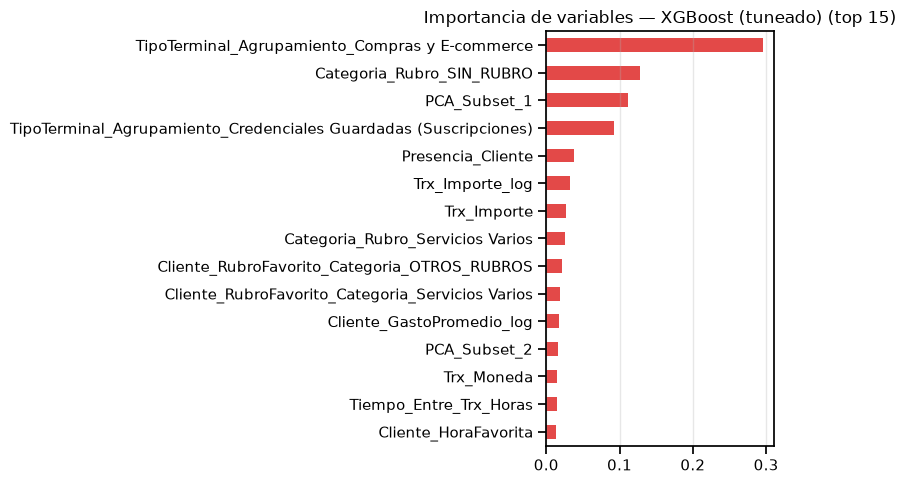

Top 5:
TipoTerminal_Agrupamiento_Compras y E-commerce                     0.2959
Categoria_Rubro_SIN_RUBRO                                          0.1277
PCA_Subset_1                                                       0.1108
TipoTerminal_Agrupamiento_Credenciales Guardadas (Suscripciones)   0.0924
Presencia_Cliente                                                  0.0380


In [24]:
# Importancia de variables del modelo final (si es de árboles) o coeficientes (si es lineal)
est = mejor_modelo.named_steps['clf'] if isinstance(mejor_modelo, Pipeline) else mejor_modelo
if hasattr(est, 'feature_importances_'):
    imp = pd.Series(est.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
    titulo = 'Importancia de variables'
else:
    imp = pd.Series(est.coef_[0], index=X.columns).sort_values(key=abs, ascending=False).head(15)
    titulo = 'Coeficientes (variables estandarizadas)'
fig, ax = plt.subplots(figsize=(8, 5))
imp.iloc[::-1].plot(kind='barh', ax=ax, color=COLOR_MODELO[n_base]); ax.set_title(f'{titulo} — {mejor_nombre} (top 15)')
ax.grid(axis='x', alpha=.3)
plt.tight_layout(); plt.show()
print('Top 5:'); print(imp.head(5).round(4).to_string())

**Comentario.** El modelo final se apoya sobre todo en el **canal**: `TipoTerminal_Agrupamiento_Compras y E-commerce` concentra el 29,6% de la importancia. Lo siguen `Categoria_Rubro_SIN_RUBRO` (12,8%; las transacciones sin rubro no tienen ningún fraude, ver la tabla de la sección 0.1), `PCA_Subset_1` (11,1%), las credenciales guardadas (9,2%) y la presencia del cliente (3,8%). Es coherente con el EDA de los TP1 y TP2 y con el árbol de la sección 5.1.

Dos advertencias. Esta importancia (por ganancia) dice *cuánto* usa el modelo cada variable, no en qué dirección empuja. Y la moneda, que en el EDA era de las variables más fuertes, no aparece en el top 5: probablemente porque su información también está dentro de `PCA_Subset_1` (en el TP2, la moneda era una de las variables de mayor peso en esa componente).

### 6.3 Umbral de decisión
Por defecto los modelos clasifican como fraude si la probabilidad > 0,5, pero ese umbral no es sagrado en un problema desbalanceado. La curva Precision-Recall muestra el *trade-off*. Elegimos el umbral que maximiza F1 **en validación** y lo evaluamos en test (el negocio podría elegir otro punto según el costo relativo de un fraude no detectado vs. una alerta falsa).

Umbral óptimo (máx F1 en validación): 0.1780


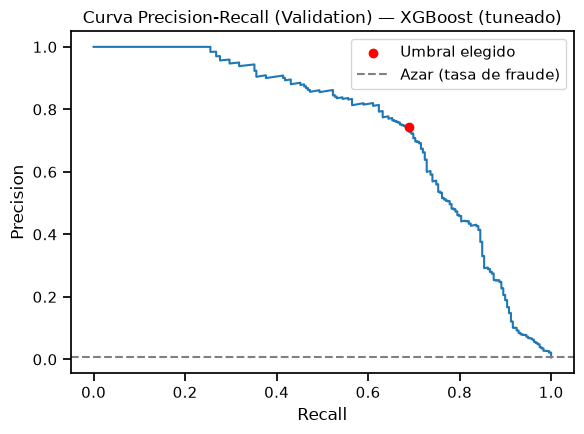

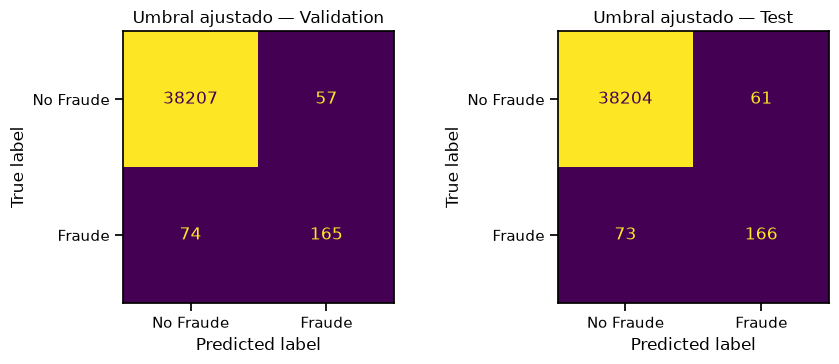

,Accuracy,Precision,Recall,F1
Conjunto,,,,
Validation,0.9966,0.7432,0.6904,0.7158
Test,0.9965,0.7313,0.6946,0.7124


In [25]:
s_val  = get_score(mejor_modelo, X_val)
s_test = get_score(mejor_modelo, X_test)

prec, rec, thr = precision_recall_curve(y_val, s_val)
f1s = 2*prec[:-1]*rec[:-1]/np.clip(prec[:-1]+rec[:-1], 1e-12, None)
umbral = thr[np.argmax(f1s)]
print(f'Umbral óptimo (máx F1 en validación): {umbral:.4f}')

fig, ax = plt.subplots(figsize=(6,4.5))
ax.plot(rec, prec); ax.scatter(rec[np.argmax(f1s)], prec[np.argmax(f1s)], color='red', zorder=5, label='Umbral elegido')
ax.axhline(y_val.mean(), ls='--', color='gray', label='Azar (tasa de fraude)')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.set_title(f'Curva Precision-Recall (Validation) — {mejor_nombre}')
ax.legend(); plt.tight_layout(); plt.show()

filas = []
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, (cj, s, yc) in zip(axes, [('Validation', s_val, y_val), ('Test', s_test, y_test)]):
    pred = (s >= umbral).astype(int)
    filas.append({'Conjunto': cj, 'Accuracy': accuracy_score(yc, pred), 'Precision': precision_score(yc, pred, zero_division=0),
                  'Recall': recall_score(yc, pred), 'F1': f1_score(yc, pred)})
    ConfusionMatrixDisplay(confusion_matrix(yc, pred), display_labels=['No Fraude','Fraude']).plot(ax=ax, colorbar=False, values_format='d')
    ax.set_title(f'Umbral ajustado — {cj}')
plt.tight_layout(); plt.show()
display(pd.DataFrame(filas).set_index('Conjunto'))

**Comentario.** El umbral que maximiza el F1 en validación es **0,1780**, muy por debajo del 0,5 por defecto. Con ese umbral el modelo logra, en validación, Precision 0,7432, Recall 0,6904 y F1 0,7158, y en **test** Precision 0,7313, Recall 0,6946 y **F1 0,7124**. Los valores son casi iguales en los dos conjuntos: buena señal de que el umbral no quedó sobreajustado a validación.

Comparado con el umbral 0,5 (en test, Precision 0,8667 y Recall 0,5983; ver la tabla de la sección 6.4), bajar a 0,1780 cambia 13,5 puntos de precision por 9,6 de recall. El F1 casi no se mueve, pero en la práctica significa detectar 23 fraudes más del test (166 contra 143) a cambio de 39 falsas alarmas más (61 contra 22). Si eso conviene o no depende del costo de cada error, que es justamente lo que analiza la sección siguiente.

### 6.4 Trade-off de negocio: ¿cuántos fraudes detectamos y a qué costo?

El umbral de 0,5 (o el que maximiza F1) trata igual a un fraude no detectado y a una falsa alarma, pero para un banco **no cuestan lo mismo**: un fraude perdido es una pérdida económica y de confianza del cliente, mientras que una falsa alarma es una molestia y un costo de revisión. Por eso analizamos qué pasa si bajamos el umbral para priorizar el Recall, mostrando en cantidades absolutas cuántos fraudes detectamos, cuántas alertas se generan y cuántas son falsas alarmas.

,Fraudes detectados,Fraudes perdidos,Recall,Precision,Alertas totales,Falsas alarmas
Umbral,,,,,,
0.5000,143,96,0.5983,0.8667,165,22
0.4000,149,90,0.6234,0.8371,178,29
0.3000,158,81,0.6611,0.7861,201,43
0.2000,165,74,0.6904,0.7432,222,57
0.1500,168,71,0.7029,0.6914,243,75
0.1000,175,64,0.7322,0.6364,275,100
0.0500,182,57,0.7615,0.5385,338,156


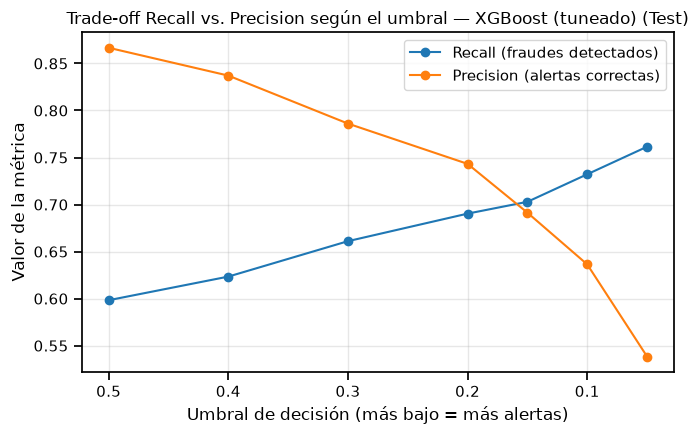

In [26]:
umbrales = [0.5, 0.4, 0.3, 0.2, 0.15, 0.1, 0.05]
n_fraudes = int(y_test.sum())
filas = []
for t in umbrales:
    pred = (s_test >= t)
    tp = int((pred & (y_test.values == 1)).sum())
    fp = int((pred & (y_test.values == 0)).sum())
    filas.append({'Umbral': t,
                  'Fraudes detectados': tp,
                  'Fraudes perdidos': n_fraudes - tp,
                  'Recall': tp / n_fraudes,
                  'Precision': tp / max(tp + fp, 1),
                  'Alertas totales': tp + fp,
                  'Falsas alarmas': fp})
tabla_umbral = pd.DataFrame(filas).set_index('Umbral')
display(tabla_umbral)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(tabla_umbral.index, tabla_umbral['Recall'], marker='o', label='Recall (fraudes detectados)')
ax.plot(tabla_umbral.index, tabla_umbral['Precision'], marker='o', label='Precision (alertas correctas)')
ax.invert_xaxis()
ax.set_xlabel('Umbral de decisión (más bajo = más alertas)')
ax.set_ylabel('Valor de la métrica')
ax.set_title(f'Trade-off Recall vs. Precision según el umbral — {mejor_nombre} (Test)')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Conclusión.** Con el umbral por defecto (0,5) se detectan 143 de los 239 fraudes del test (Recall 0,5983) con una Precision de 0,8667: de 165 alertas, sólo 22 son falsas alarmas, pero se pierden 96 fraudes. Al bajar el umbral el Recall sube, con rendimientos decrecientes: bajarlo de 0,5 a 0,2 suma 22 fraudes detectados (165 en total) a cambio de 35 falsas alarmas más (57); bajarlo de 0,2 a 0,05 suma otros 17 fraudes (182) a cambio de 99 falsas alarmas más (156).

La elección del umbral es entonces una **decisión de negocio** que depende del costo de un fraude no detectado frente al de una falsa alarma. En la práctica, un banco no aplicaría un único umbral sino un esquema por capas: score alto → contacto inmediato con el cliente y retención preventiva de la operación; score medio → verificación adicional o revisión manual; score bajo → se aprueba. Preferimos que incluso el escalón más alto pase por una persona antes de un bloqueo definitivo: aun con umbral 0,5, 22 de las 165 alertas son operaciones legítimas, y un bloqueo injustificado lo paga un cliente. Los valores exactos pueden variar con otra partición de los datos y, como veremos en la sección 7, en producción hay que esperar un desempeño bastante inferior.

#### Presupuesto de alertas: ¿cuántos fraudes encontramos si sólo podemos revisar el top-k%?

En la práctica el equipo de prevención no revisa "todo lo que supere el umbral": tiene una **capacidad de revisión** limitada. Si ordenamos las transacciones de test por score y revisamos sólo las k% más riesgosas, ¿qué fracción de los fraudes capturamos?

,alertas,fraudes encontrados,% de los fraudes,precision
% revisado,,,,
0.2500,97,93,38.9121,0.9588
0.5000,193,158,66.1088,0.8187
1.0000,386,187,78.2427,0.4845
2.0000,771,208,87.0293,0.2698
5.0000,1926,229,95.8159,0.1189
10.0000,3851,234,97.9079,0.0608


Umbral elegido (0.1780): 227 alertas (0.59% de las transacciones), detecta el 69.5% de los fraudes.
Regla dólares y e-commerce: 292 alertas (0.76%), detecta el 28.5%.


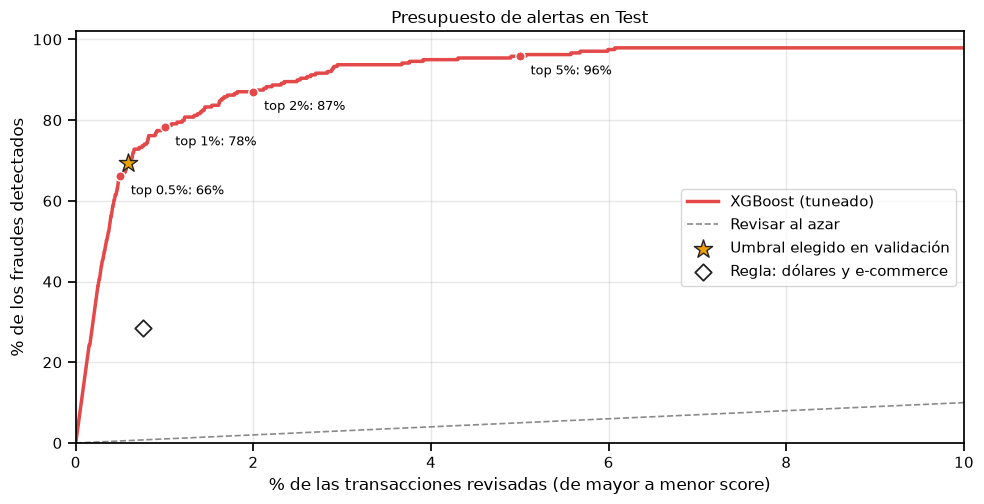

In [27]:
orden = np.argsort(-s_test, kind='mergesort')
y_ord = y_test.values[orden]
n_te, n_fr = len(y_ord), int(y_ord.sum())
acumulado = np.cumsum(y_ord)

filas = []
for k in [0.0025, 0.005, 0.01, 0.02, 0.05, 0.10]:
    m_ = int(np.ceil(k * n_te))
    filas.append({'% revisado': k * 100, 'alertas': m_, 'fraudes encontrados': int(acumulado[m_ - 1]),
                  '% de los fraudes': acumulado[m_ - 1] / n_fr * 100, 'precision': acumulado[m_ - 1] / m_})
display(pd.DataFrame(filas).set_index('% revisado').round(4))

pred_umbral = s_test >= umbral
pred_regla = regla.predict(X_test)
print(f"Umbral elegido ({umbral:.4f}): {pred_umbral.sum()} alertas ({pred_umbral.mean():.2%} de las transacciones), "
      f"detecta el {recall_score(y_test, pred_umbral):.1%} de los fraudes.")
print(f"Regla dólares y e-commerce: {pred_regla.sum()} alertas ({pred_regla.mean():.2%}), detecta el {recall_score(y_test, pred_regla):.1%}.")

fig, ax = plt.subplots(figsize=(10, 5.2))
tope = int(0.10 * n_te)
ax.plot(np.arange(1, tope + 1) / n_te * 100, acumulado[:tope] / n_fr * 100, color=COLOR_MODELO[n_base], lw=2.5, label=mejor_nombre)
ax.plot([0, 10], [0, 10], color=GRIS, ls='--', lw=1.2, label='Revisar al azar')
for k in [0.005, 0.01, 0.02, 0.05]:
    m_ = int(np.ceil(k * n_te)); v = acumulado[m_ - 1] / n_fr * 100
    ax.scatter(k * 100, v, color=COLOR_MODELO[n_base], s=45, edgecolor='white', zorder=5)
    ax.text(k * 100 + 0.12, v - 4.5, f'top {k*100:g}%: {v:.0f}%', fontsize=9)
ax.scatter(pred_umbral.mean() * 100, recall_score(y_test, pred_umbral) * 100, marker='*', s=190, color='#eda100',
           edgecolor='#222222', zorder=6, label='Umbral elegido en validación')
ax.scatter(pred_regla.mean() * 100, recall_score(y_test, pred_regla) * 100, marker='D', s=70, color='white',
           edgecolor='#222222', linewidth=1.3, zorder=6, label='Regla: dólares y e-commerce')
ax.set_xlim(0, 10); ax.set_ylim(0, 102)
ax.set_xlabel('% de las transacciones revisadas (de mayor a menor score)'); ax.set_ylabel('% de los fraudes detectados')
ax.set_title('Presupuesto de alertas en Test'); ax.legend(loc='center right'); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Comentario.** Ésta es probablemente la vista más útil para el equipo de prevención. Ordenando las 38.504 transacciones de test por score, revisando sólo el **0,5% más riesgoso (193 alertas) se encuentran 158 fraudes, el 66,1% del total, con una precision de 0,819**: 8 de cada 10 alertas son fraude. Con el 1% (386 alertas) se llega al 78,2% de los fraudes, con el 2% al 87,0% y con el 5% al 95,8%. A partir de ahí los rendimientos son muy decrecientes: pasar del 5% al 10% (el doble de trabajo) suma apenas 5 fraudes.

Con el umbral elegido en validación se generan 227 alertas (0,59% de las transacciones) y se detecta el 69,5% de los fraudes; la regla de negocio, con una carga de revisión parecida (292 alertas, 0,76%), detecta sólo el 28,5%. **Con el mismo esfuerzo de revisión, el modelo encuentra más del doble de fraudes que la regla.**

## 7. ¿Qué tan confiable es esta evaluación?

Dos preguntas antes de cerrar: (1) con sólo 239 fraudes en test, ¿cuánto ruido tienen las métricas? y (2) ¿el resultado se sostiene cuando el modelo tiene que evaluar a clientes que nunca vio?

### 7.1 Intervalos de confianza por bootstrap
Remuestreamos con reposición las transacciones de test 1.000 veces y recalculamos las métricas del modelo final (con el umbral ya elegido en validación). Los percentiles 2,5 y 97,5 dan un intervalo de confianza del 95%.

,valor en test,IC95% inferior,IC95% superior,± aprox.
F1,0.7124,0.6651,0.7545,0.0447
Precision,0.7313,0.6741,0.7866,0.0563
Recall,0.6946,0.6349,0.7500,0.0576
PR-AUC,0.7579,0.7095,0.8035,0.0470


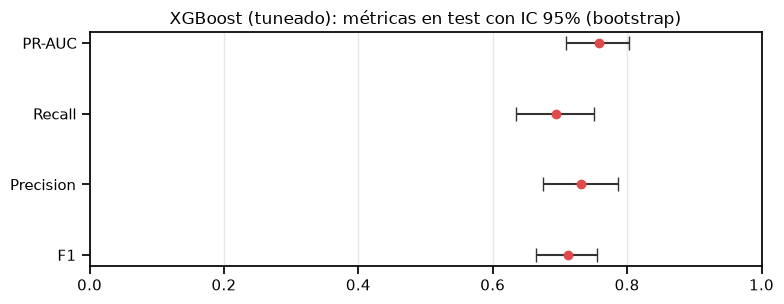

In [28]:
rng = np.random.default_rng(SEED)
yt, pt = y_test.values, (s_test >= umbral).astype(int)
boot = []
for _ in range(1000):
    i = rng.integers(0, len(yt), len(yt))
    boot.append({'F1': f1_score(yt[i], pt[i]), 'Precision': precision_score(yt[i], pt[i], zero_division=0),
                 'Recall': recall_score(yt[i], pt[i]), 'PR-AUC': average_precision_score(yt[i], s_test[i])})
boot = pd.DataFrame(boot)
puntual = {'F1': f1_score(yt, pt), 'Precision': precision_score(yt, pt), 'Recall': recall_score(yt, pt),
           'PR-AUC': average_precision_score(yt, s_test)}
ic = pd.DataFrame({'valor en test': puntual, 'IC95% inferior': boot.quantile(0.025), 'IC95% superior': boot.quantile(0.975)})
ic['± aprox.'] = (ic['IC95% superior'] - ic['IC95% inferior']) / 2
display(ic.round(4))

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.errorbar(ic['valor en test'], range(len(ic)), xerr=[ic['valor en test'] - ic['IC95% inferior'], ic['IC95% superior'] - ic['valor en test']],
            fmt='o', color=COLOR_MODELO[n_base], ecolor='#333333', capsize=5)
ax.set_yticks(range(len(ic))); ax.set_yticklabels(ic.index); ax.set_xlim(0, 1); ax.grid(axis='x', alpha=.3)
ax.set_title(f'{mejor_nombre}: métricas en test con IC 95% (bootstrap)')
plt.tight_layout(); plt.show()

**Comentario.** Con 239 fraudes en test, las métricas tienen un margen de error considerable. El F1 del modelo final es 0,7124 con un intervalo de confianza del 95% de [0,6651, 0,7545], es decir, **± 0,045** aproximadamente; la PR-AUC de 0,7579 va de 0,7095 a 0,8035, la Precision de 0,6741 a 0,7866 y el Recall de 0,6349 a 0,7500.

Consecuencia práctica: **diferencias de F1 menores a ~0,05 entre dos modelos no se pueden distinguir con este test**, así que la mejora de ~0,01 que aportó el ajuste de hiperparámetros (sección 6.2) está dentro del ruido. Además, este intervalo trata a cada transacción como independiente; como los fraudes de un mismo cliente vienen en episodios (sección 7.2), el margen real es algo mayor.

### 7.2 Evaluación por cliente

El split aleatorio reparte las transacciones de cada cliente entre train y test. Eso importa en fraude, porque los fraudes de un mismo cliente suelen venir **en episodios** (varias operaciones del mismo atacante en poco tiempo): si parte del episodio queda en train, el modelo puede "reconocer" al cliente en test en lugar de haber aprendido un patrón general. Primero medimos cuánto pasa esto en nuestro split.

In [29]:
fraudes_por_cliente = y.groupby(grupos).sum()
afectados = fraudes_por_cliente[fraudes_por_cliente > 0]
print(f"Clientes con al menos un fraude: {len(afectados)} de {grupos.nunique()} "
      f"({len(afectados) / grupos.nunique():.0%}), con {afectados.mean():.1f} fraudes en promedio cada uno.")

clientes_train = set(grupos.loc[X_train.index])
clientes_con_fraude_train = set(grupos.loc[y_train.index[y_train == 1]])
cli_fraudes_test = grupos.loc[y_test.index[y_test == 1]]
print(f"Fraudes de test cuyo cliente también está en train: {cli_fraudes_test.isin(clientes_train).mean():.1%}")
print(f"Fraudes de test cuyo cliente tiene OTROS fraudes en train: {cli_fraudes_test.isin(clientes_con_fraude_train).mean():.1%}")

Clientes con al menos un fraude: 352 de 716 (49%), con 3.4 fraudes en promedio cada uno.
Fraudes de test cuyo cliente también está en train: 99.6%
Fraudes de test cuyo cliente tiene OTROS fraudes en train: 79.5%


**Comentario.** El 49% de los clientes del dataset (352 de 716) sufrió al menos un fraude, con 3,4 fraudes en promedio cada uno: el fraude viene en **episodios por cliente**, no como eventos aislados. Y el split aleatorio reparte esos episodios: el **99,6%** de los fraudes de test pertenece a un cliente que también está en train, y el **79,5%** a un cliente que tiene *otros fraudes* en train. Es decir, en la gran mayoría de los casos el modelo ya vio, durante el entrenamiento, otros fraudes del mismo cliente. Puede estar reconociendo "este cliente está teniendo un episodio" en lugar de haber aprendido un patrón general de fraude.

Para medir el efecto reentrenamos **la configuración del modelo final** con dos esquemas de 5 folds sobre todo el dataset:

- **Aleatorio** (`StratifiedKFold`): como el split de este TP.
- **Por cliente** (`StratifiedGroupKFold` con `Cliente_Id` como grupo): **ningún cliente está a la vez en train y en test**, que es la situación de un cliente nuevo o de un patrón que el modelo no vio.

En cada fold apartamos un 25% del entrenamiento para elegir el umbral (al azar en el esquema aleatorio, por clientes enteros en el esquema por cliente), igual que hicimos con validación. Como referencia evaluamos también la regla de negocio en cada fold.

F1        PR-AUC        Precision        Recall         \
              mean    std   mean    std      mean    std   mean    std   
Esquema                                                                  
Aleatorio   0.7003 0.0236 0.7496 0.0320    0.7919 0.0677 0.6313 0.0355   
Por cliente 0.2799 0.0534 0.2601 0.0566    0.2823 0.0587 0.3235 0.1537   

            F1 regla         
                mean    std  
Esquema                      
Aleatorio     0.2486 0.0389  
Por cliente   0.2516 0.0506

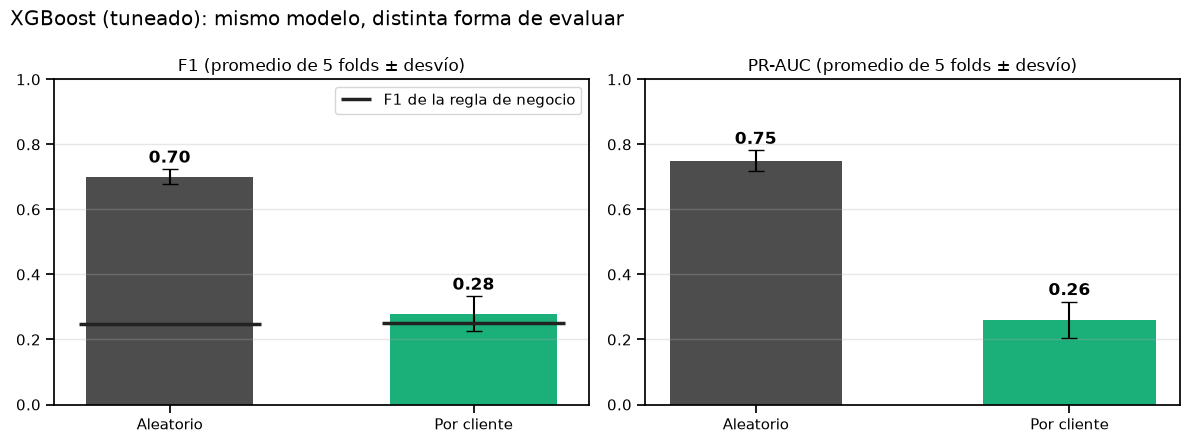

In [30]:
esquemas = {'Aleatorio': StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED).split(X, y),
            'Por cliente': StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED).split(X, y, grupos)}
pred_regla_total = regla.predict(X)
filas = []
for esquema, particiones in esquemas.items():
    for k, (tr, te) in enumerate(particiones):
        rng = np.random.default_rng(SEED + k)
        if esquema == 'Por cliente':
            cl = grupos.iloc[tr].unique()
            es_val = grupos.iloc[tr].isin(rng.choice(cl, size=len(cl) // 4, replace=False)).values
        else:
            es_val = rng.random(len(tr)) < 0.25
        i_fit, i_val = tr[~es_val], tr[es_val]
        modelo = clone(mejor_modelo).fit(X.iloc[i_fit], y.iloc[i_fit])
        u = umbral_max_f1(y.iloc[i_val], get_score(modelo, X.iloc[i_val]))
        s = get_score(modelo, X.iloc[te]); yte = y.iloc[te]
        filas.append({'Esquema': esquema, 'Fold': k + 1, 'F1': f1_score(yte, s >= u), 'PR-AUC': average_precision_score(yte, s),
                      'Precision': precision_score(yte, s >= u, zero_division=0), 'Recall': recall_score(yte, s >= u),
                      'F1 regla': f1_score(yte, pred_regla_total[te]), 'Fraudes en test': int(yte.sum())})
folds = pd.DataFrame(filas)
resumen_esquemas = folds.groupby('Esquema')[['F1', 'PR-AUC', 'Precision', 'Recall', 'F1 regla']].agg(['mean', 'std'])
display(resumen_esquemas.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colores_esq = {'Aleatorio': '#4d4d4d', 'Por cliente': '#1baf7a'}
for ax, met in zip(axes, ['F1', 'PR-AUC']):
    medias = folds.groupby('Esquema')[met].mean().reindex(['Aleatorio', 'Por cliente'])
    desvios = folds.groupby('Esquema')[met].std().reindex(['Aleatorio', 'Por cliente'])
    ax.bar(medias.index, medias.values, yerr=desvios.values, capsize=6, width=0.55,
           color=[colores_esq[e] for e in medias.index])
    for i, v in enumerate(medias.values):
        ax.text(i, v + desvios.values[i] + 0.02, f'{v:.2f}', ha='center', fontweight='bold')
    if met == 'F1':
        regla_media = folds.groupby('Esquema')['F1 regla'].mean().reindex(['Aleatorio', 'Por cliente'])
        ax.hlines(regla_media.values, [-0.3, 0.7], [0.3, 1.3], color='#222222', lw=2.5, label='F1 de la regla de negocio')
        ax.legend(loc='upper right')
    ax.set_ylim(0, 1); ax.set_title(f'{met} (promedio de 5 folds ± desvío)'); ax.grid(axis='y', alpha=.3)
plt.suptitle(f'{mejor_nombre}: mismo modelo, distinta forma de evaluar', x=0.01, ha='left')
plt.tight_layout(); plt.show()

**Comentario.** El resultado es contundente. Con el esquema **aleatorio**, el modelo final logra en promedio **F1 0,7003 y PR-AUC 0,7496** (desvíos entre folds de 0,0236 y 0,0320), en línea con lo que medimos en el test de este TP. Con el esquema **por cliente**, el mismo modelo cae a **F1 0,2799 y PR-AUC 0,2601**, con Precision 0,2823 y Recall 0,3235. Frente a la regla de negocio, que no necesita reconocer clientes (F1 0,2486 en el esquema aleatorio y 0,2516 por cliente), la ventaja del modelo pasa de unos 0,45 a apenas 0,03, menos que el desvío entre folds (0,0534).

**Lectura:** el F1 de ~0,71 del split que pide la consigna es un **techo optimista**: buena parte de lo que el modelo "sabe" es reconocer clientes que ya vio con fraude, y frente a un cliente nuevo rinde parecido a la regla simple. No es que el modelo no sirva (su PR-AUC por cliente sigue siendo unas 40 veces la tasa de fraude), sino que **su ventaja real sobre una regla es mucho menor que la que sugiere el split aleatorio**. Para mejorarla habría que construir variables que no funcionen como una "huella" del cliente (por ejemplo, desvíos respecto de su propio comportamiento) y comparar los modelos directamente con validación por cliente.

## 8. Resumen y conclusiones

In [31]:
def fila(nombre, pred, score=None):
    return {'Modelo': nombre, 'Precision': precision_score(y_test, pred, zero_division=0), 'Recall': recall_score(y_test, pred),
            'F1': f1_score(y_test, pred), 'PR-AUC': average_precision_score(y_test, score) if score is not None else np.nan}

resumen = pd.DataFrame([
    fila('Baseline (stratified)', baseline_st.predict(X_test), get_score(baseline_st, X_test)),
    fila('Regla: dólares y e-commerce', regla.predict(X_test)),
    fila(f'{mejor_nombre}, umbral 0,5', mejor_modelo.predict(X_test), s_test),
    fila(f'{mejor_nombre}, umbral elegido en val ({umbral:.4f})', (s_test >= umbral).astype(int), s_test),
]).set_index('Modelo')
print('TEST (split aleatorio 60/20/20):')
display(resumen.round(4))
print(f"IC 95% del F1 en test: [{ic.loc['F1', 'IC95% inferior']:.3f}, {ic.loc['F1', 'IC95% superior']:.3f}]")
m = folds.groupby('Esquema')[['F1', 'PR-AUC']].mean()
print(f"5 folds aleatorios:  F1 {m.loc['Aleatorio', 'F1']:.3f} | PR-AUC {m.loc['Aleatorio', 'PR-AUC']:.3f}")
print(f"5 folds por cliente: F1 {m.loc['Por cliente', 'F1']:.3f} | PR-AUC {m.loc['Por cliente', 'PR-AUC']:.3f}")

TEST (split aleatorio 60/20/20):


,Precision,Recall,F1,PR-AUC
Modelo,,,,
Baseline (stratified),0.0212,0.0209,0.0211,0.0065
Regla: dólares y e-commerce,0.2329,0.2845,0.2561,NaN
"XGBoost (tuneado), umbral 0,5",0.8667,0.5983,0.7079,0.7579
"XGBoost (tuneado), umbral elegido en val (0.1780)",0.7313,0.6946,0.7124,0.7579


IC 95% del F1 en test: [0.665, 0.754]
5 folds aleatorios:  F1 0.700 | PR-AUC 0.750
5 folds por cliente: F1 0.280 | PR-AUC 0.260


### Conclusiones finales

1. **Métrica.** Descartamos el Accuracy (el baseline `most_frequent` llega a 0,9938 sin detectar ningún fraude). Comparamos y ajustamos los modelos con **PR-AUC**, que no depende del umbral, y usamos **F1** para elegir el umbral de decisión en validación. Elegir con F1 a umbral fijo resultó engañoso: la configuración de Random Forest que había elegido esa búsqueda mejoraba el F1 a 0,5 pero empeoraba el modelo (PR-AUC de 0,6790 a 0,6379, sección 6.0).
2. **Baselines → lineales → árboles.** La regla "dólares y e-commerce" (F1 0,2561 en test) es el piso real. Los lineales tienen peor F1 que la regla con umbral 0,5, pero mejor ranking (PR-AUC ~0,40), y su curva queda por encima del punto de la regla. Los mejores son los ensambles de árboles, XGBoost (PR-AUC 0,7201 en validación) y Random Forest (0,6790), porque capturan interacciones como las que muestra el árbol de la sección 5.1 (dólares + ráfaga + e-commerce).
3. **Sobreajuste.** El árbol sin restricciones memoriza el train (F1 1,0000 contra 0,4485 en validación). Los ensambles también se aprenden el train casi de memoria, pero generalizan mucho mejor.
4. **Hiperparámetros y umbral.** El modelo final es **XGBoost tuneado** (`max_depth=8`, `learning_rate=0.1`, `scale_pos_weight=10`) con umbral **0,1780** elegido en validación. En test logra **Precision 0,7313, Recall 0,6946, F1 0,7124 y PR-AUC 0,7579**. El ajuste de hiperparámetros aportó poco (~0,01 de F1, dentro del ruido); lo que más pesó fue elegir el modelo con la métrica correcta y ajustar el umbral.
5. **Para el negocio.** Revisando el 1% de las transacciones con mayor score se detecta el 78,2% de los fraudes. Con el umbral elegido, el modelo detecta el 69,5% con una carga de revisión parecida a la de la regla, que detecta el 28,5%. El umbral final es una decisión de negocio que depende del costo de cada error, y proponemos que las alertas pasen por revisión humana antes de cualquier bloqueo.
6. **¿Qué tan confiable es?** Con 239 fraudes en test, el F1 tiene un margen de ± 0,045. Y el split aleatorio es optimista: el 79,5% de los fraudes de test tiene otro fraude del mismo cliente en train, y evaluando por cliente el F1 cae de 0,7003 a 0,2799, apenas por encima de la regla (0,2516).
7. **Próximos pasos.** (a) comparar y ajustar los modelos directamente con validación por cliente; (b) recuperar la fecha desde el archivo original para validar también con un corte temporal (en el TP2 vimos que ~94% del fraude está en octubre–diciembre); (c) construir variables que no funcionen como "huella" del cliente; (d) probar SMOTE o submuestreo, otros boostings (LightGBM, CatBoost) y un `HistGradientBoosting` sin *early stopping*.